#Texas Real Estate Market Analysis

**Author:** Enrico Ceci

**Date:** 2025-09-25

*Note: this notebook was developed in R

In [ ]:
knitr::opts_chunk$set(
  echo = TRUE,
  eval = FALSE,
  warning = FALSE,
  message = FALSE,
  fig.align = "center"
)

In [ ]:
if (!requireNamespace("moments", quietly = TRUE)) {install.packages("moments")}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# LIBRARY IMPORT

library(dplyr)
library(ggplot2)
library(knitr)
library(moments)
library(tidyr)

In [ ]:
# DATASET IMPORT

file_id = "1O4If8876MTwstkrZX0BqpQ_BxcsIMEko"

download_url = paste0(
  "https://drive.google.com/uc?export=download&id=",
  file_id
)

download.file(
  download_url,
  destfile = "realestate_texas.csv",
  mode = "wb"
)

re_data = read.csv("realestate_texas.csv")

In [ ]:
# DATASET PREVIEW

head(re_data)

,city,year,month,sales,volume,median_price,listings,months_inventory
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,Beaumont,2010,1,83,14.162,163800,1533,9.5
2,Beaumont,2010,2,108,17.690,138200,1586,10.0
3,Beaumont,2010,3,182,28.701,122400,1689,10.6
4,Beaumont,2010,4,200,26.819,123200,1708,10.6
5,Beaumont,2010,5,202,28.833,123100,1771,10.9
6,Beaumont,2010,6,189,27.219,122800,1803,11.1


In [ ]:
# CHECK NUMBER OF ROWS IN DATASET

N <- nrow(re_data)

print(N)

[1] 240


# 1. Variable Analysis

**Request:** Identify and describe the types of statistical variables present in the dataset. Assess how to handle variables that imply a time dimension and comment on the type of analysis that can be conducted on each variable.

| Variable name      | Meaning                                                             | Variable type                                                                  |
| ------------------ | ------------------------------------------------------------------- | ------------------------------------------------------------------------------ |
| `city`             | city                                                                | Nominal qualitative variable                                                   |
| `year`             | reference year                                                      | Ordinal quantitative variable to be treated as an ordinal qualitative variable |
| `month`            | reference month                                                     | Cyclical nominal qualitative variable encoded numerically                      |
| `sales`            | total number of sales                                               | Discrete quantitative variable                                                 |
| `volume`           | total sales value in millions of dollars                            | Continuous quantitative variable                                               |
| `median_price`     | median sale price in dollars                                        | Continuous quantitative variable                                               |
| `listings`         | total number of active listings                                     | Discrete quantitative variable                                                 |
| `months_inventory` | number of months required to sell all current and previous listings | Continuous quantitative variable                                               |

#

Continuous quantitative variables are measured on a ratio scale.

* For quantitative variables, analyses concerning measures of location, dispersion, and shape can be conducted.

* For qualitative variables, the same analyses cannot be conducted because they require numerical values rather than categories; the exception is the identification of the mode, which is based on frequency analysis.

The variables `city`, `year`, and `month` essentially play a role equivalent to that of an identifier variable. In fact, there is no possibility for the frequency of one city to be lower than that of the others, and the same applies to the other two variables.


#2. Measures of Location, Variability, and Shape

**Request:** Calculate measures of location, variability, and shape for all variables for which it makes sense to do so; for the others, create a frequency distribution.

In light of the consideration presented in the response to Request 1, the variables `city`, `year`, and `month` have equal absolute frequencies. The variable that determines the frequency of the observations is `month`, because the observations are recorded monthly.

Each city, four in total, is observed for twelve months in each year from 2010 to 2014. Therefore, the name of each city is repeated across 60 rows:

12 months * 5 years = 60 rows

As a result, even the mode becomes an irrelevant measure to calculate, as does the Gini index.


## 2.1 Measures of location

In [ ]:
summary(re_data)

        city          year          month           sales      
 Length   :240   Min.   :2010   Min.   : 1.00   Min.   : 79.0  
 N.unique :  4   1st Qu.:2011   1st Qu.: 3.75   1st Qu.:127.0  
 N.blank  :  0   Median :2012   Median : 6.50   Median :175.5  
 Min.nchar:  5   Mean   :2012   Mean   : 6.50   Mean   :192.3  
 Max.nchar: 21   3rd Qu.:2013   3rd Qu.: 9.25   3rd Qu.:247.0  
                 Max.   :2014   Max.   :12.00   Max.   :423.0  
     volume        median_price       listings    months_inventory
 Min.   : 8.166   Min.   : 73800   Min.   : 743   Min.   : 3.400  
 1st Qu.:17.660   1st Qu.:117300   1st Qu.:1026   1st Qu.: 7.800  
 Median :27.062   Median :134500   Median :1618   Median : 8.950  
 Mean   :31.005   Mean   :132665   Mean   :1738   Mean   : 9.193  
 3rd Qu.:40.893   3rd Qu.:150050   3rd Qu.:2056   3rd Qu.:10.950  
 Max.   :83.547   Max.   :180000   Max.   :3296   Max.   :14.900  

| Variable | Min. | 1° quartile | Median | Mean | 3° quartile | Max |
|---|---:|---:|---:|---:|---:|---:|
| `year` | 2010 | 2011 | 2012 | 2012 | 2013 | 2014 |
| `month` | 1.00 | 3.75 | 6.50 | 6.50 | 9.25 | 12.00 |
| `sales` | 79.0 | 127.0 | 175.5 | 192.3 | 247.0 | 423.0 |
| `volume` | 8.166 | 17.660 | 27.062 | 31.005 | 40.893 | 83.547 |
| `median_price` | 73.800 | 117.300 | 134.500 | 132.665 | 150.050 | 180.000 |
| `listings` | 743 | 1.026 | 1.618 | 1.738 | 2.056 | 3.296 |
| `months_inventory` | 3.400 | 7.800 | 8.950 | 9.193 | 10.950 | 14.900 |

## 2.1 Measures of variability and shape


In [ ]:
# Define the function to calculate the measures
function_x_measures <- function(x, name_var) {
  c(
    Variable = name_var,
    Min = min(x),
    Max = max(x),
    IQR = IQR(x),
    Variance = var(x),
    Std_deviation = sd(x),
    CV = sd(x) / mean(x),
    Skewness = skewness(x),
    Kurtosis = kurtosis(x)
  )
}

# Select the variables of interest
vars <- re_data[
  c("sales", "volume", "median_price", "listings", "months_inventory")
]

# Calculate the measrures for each variable, obtaining a list of vectors
results_list <- lapply(
  names(vars),
  function(n) function_x_measures(vars[[n]], n)
)

# Convert the list into a table
results_tab <- do.call(rbind, results_list)

kable(
  results_tab,
  caption = "Variability and shape measures",
  digits = 2,
  align = "c",
  format.args = list(nsmall = 2)
)



Table: Variability and shape measures

|     Variable     |  Min  |  Max   |   IQR   |     Variance     |  Std_deviation   |        CV         |      Skewness      |     Kurtosis     |
|:----------------:|:-----:|:------:|:-------:|:----------------:|:----------------:|:-----------------:|:------------------:|:----------------:|
|      sales       |  79   |  423   |   120   | 6344.29951185495 | 79.6511111777793 | 0.414220296482492 | 0.718104024884959  | 2.68682359092851 |
|      volume      | 8.166 | 83.547 | 23.2335 | 277.270692404027 | 16.6514471564494 | 0.537053586805415 | 0.884742026325995  | 3.17698699708974 |
|   median_price   | 73800 | 180000 |  32750  | 513572983.089261 | 22662.148686505  | 0.170821825732064 | -0.364552878177372 | 2.37703817924446 |
|     listings     |  743  |  3296  | 1029.5  | 566568.966091353 | 752.707756098841 | 0.433083275909432 | 0.649498226273971  | 2.20820996666741 |
| months_inventory |  3.4  |  14.9  |  3.15   | 5.30688912133891 | 2.30366862229334

| Variable | Min | Max | IQR | Variance |Standard deviation | CV | Skewness | Kurtosis |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| `sales` | 79 | 423 | 120 | 6.344,30 | 79,65 | 0,414 | 0,718 | 2,687 |
| `volume` | 8,166 | 83,547 | 23,2335 | 277,27 | 16,65 | 0,537 | 0,885 | 3,177 |
| `median_price` | 73.800 | 180.000 | 32.750 | 513.572.983,09 | 22.662,15 | 0,171 | -0,365 | 2,377 |
| `listings` | 743 | 3.296 | 1.029,5 | 566.568,97 | 752,71 | 0,433 | 0,649 | 2,208 |
| `months_inventory` | 3,4 | 14,9 | 3,15 | 5,31 | 2,30 | 0,251 | 0,041 | 2,826 |

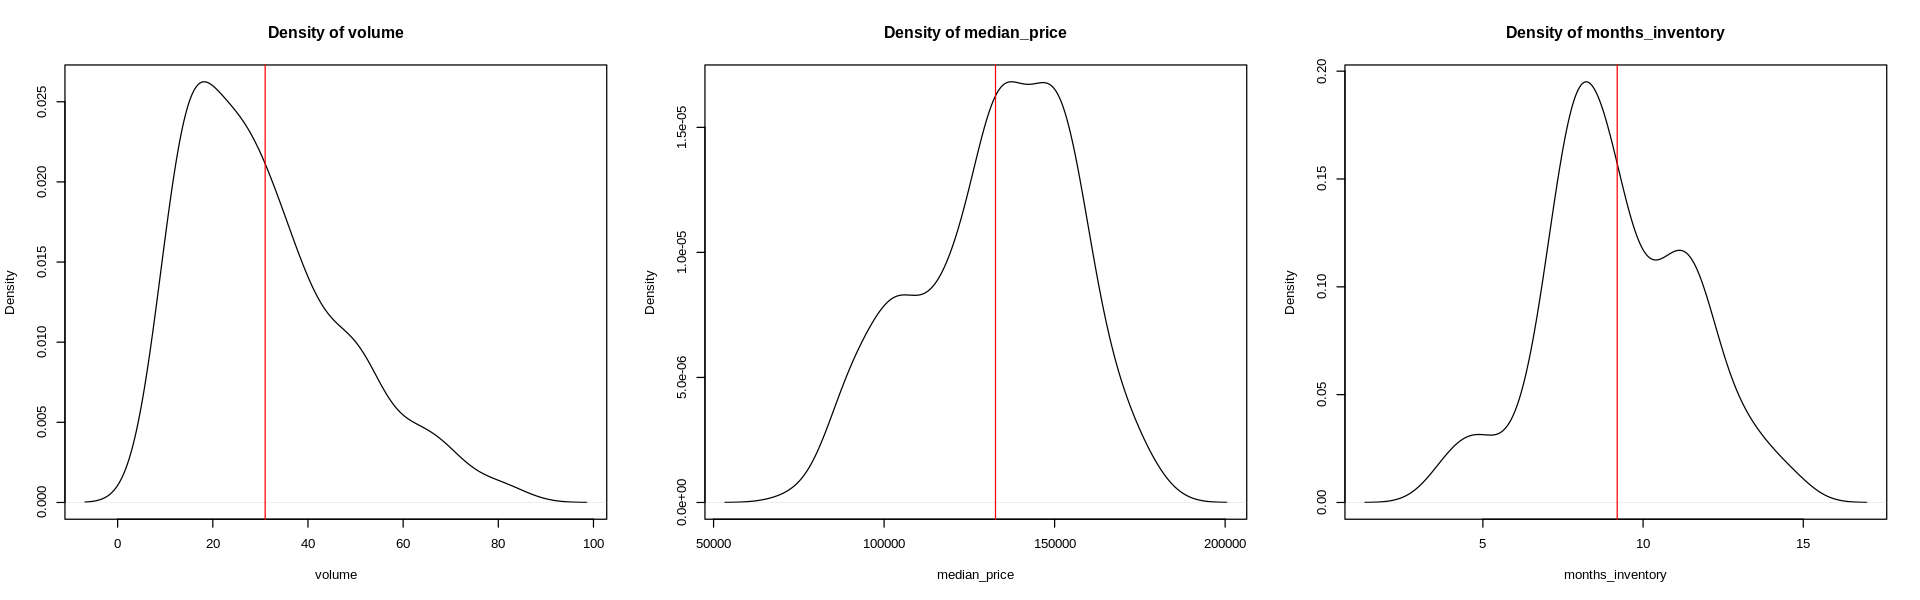

In [ ]:
# Create a vector of continuous variables for the plots
continuous_vars <- c("volume", "median_price", "months_inventory")

# Set the plotting window
par(mfrow = c(1, 3))

# Set plot size
options(repr.plot.width = 16, repr.plot.height = 5)

# Loop to create the plots
for (var in continuous_vars) {
  x <- re_data[[var]]

  plot(
    density(x),
    main = paste("Density of", var),
    xlab = var
  )

  # Axis of symmetry
  abline(v = mean(x), col = "red")
}

**Note:** As discussed above, the Gini index is not meaningful for the variables `year`, `month`, and `city`, nor is it appropriate for the quantitative variables considered in this section. For the latter, the observed values are not qualitative categories whose frequencies are to be entered into the Gini formula; rather, they are numerical realizations of quantitative variables.

# 3. Identification of the variables with the highest variability and skewness

**Request:** Which variable has the highest variability? How did you determine it? And which variable is the most skewed?

The variable with the highest variability is `volume`. It was identified by comparing the coefficients of variation. The coefficient of variation for `volume` is 53.7%, indicating that the standard deviation is nearly 54% of the mean.

The most skewed variable is again `volume`, with a skewness coefficient of 0.88. This indicates positive skewness: lower values of the variable are more frequent, and therefore the following relationship holds:

mean > median > mode


# 4. Creating Classes for a Quantitative Variable

## 4.1 Creating classes

In [ ]:
re_data$sales_cl <- cut(
  re_data$sales,
  breaks = c(70, 130, 190, 250, 310, 370, 430)
)

## 4.2 Frequency distribution

In [ ]:
ni <- table(re_data$sales_cl)
fi <- table(re_data$sales_cl) / N
Ni <- cumsum(ni)
Fi <- Ni / N

kable(
  cbind(ni, fi, Ni, Fi),
  caption = "Frequency distribution",
  digits = 2,
  align = "c",
  format.args = list(nsmall = 2)
)



Table: Frequency distribution

|          |  ni   |  fi  |   Ni   |  Fi  |
|:---------|:-----:|:----:|:------:|:----:|
|(70,130]  | 67.00 | 0.28 | 67.00  | 0.28 |
|(130,190] | 72.00 | 0.30 | 139.00 | 0.58 |
|(190,250] | 42.00 | 0.17 | 181.00 | 0.75 |
|(250,310] | 36.00 | 0.15 | 217.00 | 0.90 |
|(310,370] | 17.00 | 0.07 | 234.00 | 0.98 |
|(370,430] | 6.00  | 0.03 | 240.00 | 1.00 |

| Classe | Absolute frequency | Relative frequency | Cumulative frequency | Relative cumulative frequency |
|---|---:|---:|---:|---:|
| (70, 130] | 67 | 0,28 | 67 | 0,28 |
| (130, 190] | 72 | 0,30 | 139 | 0,58 |
| (190, 250] | 42 | 0,17 | 181 | 0,75 |
| (250, 310] | 36 | 0,15 | 217 | 0,90 |
| (310, 370] | 17 | 0,07 | 234 | 0,98 |
| (370, 430] | 6 | 0,03 | 240 | 1,00 |

##4.3 Class distribution Plot

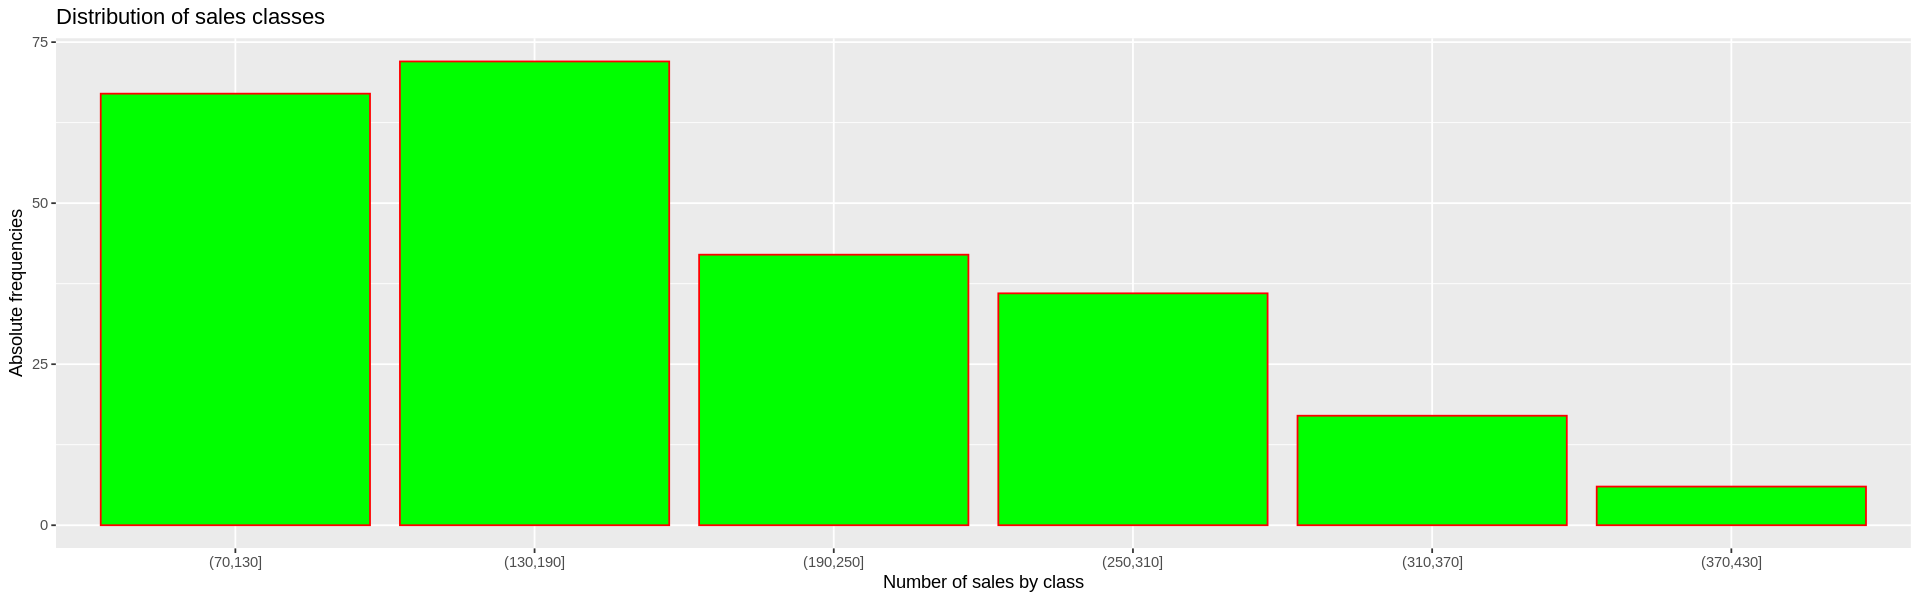

In [ ]:
ggplot(data = re_data) +
  geom_bar(
    aes(x = sales_cl),
    stat = "count",
    col = "red",
    fill = "green"
  ) +
  labs(
    title = "Distribution of sales classes",
    x = "Number of sales by class",
    y = "Absolute frequencies"
  ) +
  scale_y_continuous(breaks = seq(0, 75, 25))

##4.4 Gini Index

In [ ]:
gini.index <- function(x) {
  ni <- table(x)
  fi <- ni / length(x)
  fi2 <- fi^2
  J <- length(table(x))

  gini <- 1 - sum(fi2)
  gini.normalizzato <- gini / ((J - 1) / J)

  return(gini.normalizzato)
}

kable(
  table(re_data$sales_cl),
  caption = "Frequency distribution by class",
  digits = 2,
  align = "c",
  format.args = list(nsmall = 2)
)

kable(gini.index(re_data$sales_cl))



Table: Frequency distribution by class

|   Var1    | Freq  |
|:---------:|:-----:|
| (70,130]  | 67.00 |
| (130,190] | 72.00 |
| (190,250] | 42.00 |
| (250,310] | 36.00 |
| (310,370] | 17.00 |
| (370,430] | 6.00  |



|         x|
|---------:|
| 0.9279583|

The result is very close to 1 (0.9279583), indicating a condition close to maximum heterogeneity.

# 5. Probability Calculations

**What is the probability that a randomly selected row refers to the city of “Beaumont”?**

The probability is 25%: 60/240 = 0.25

#

**What is the probability that it refers to the month of July?**

The probability is 8.3%. Each city is observed over five years, so there are five rows corresponding to July for each of the four cities:

(5 * 4)(240) = 20/240 = 0.083

#

**What is the probability that it refers to December 2012?**

The probability is 1.7%: December 2012 appears once for each of the four cities:

20/240 = 0.017


# 6. Creating New Variables

## 6.1 Mean Price

**Request:** There is a column containing the median price; create another one representing the mean price using the other available variables.

In [ ]:
re_data$mean_price <- re_data$volume * 1000000 / re_data$sales

## 6.2 Mean price distribution by city

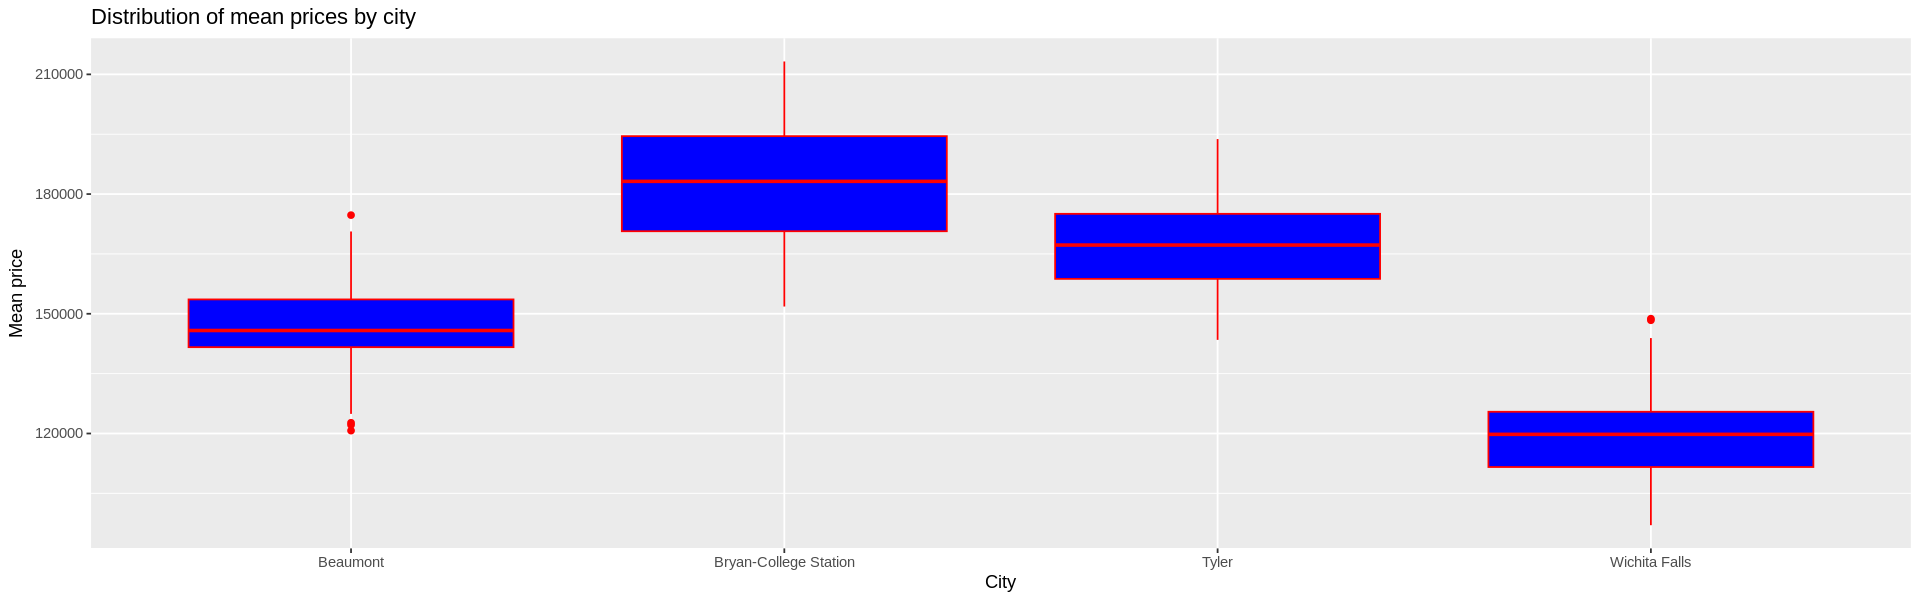

In [ ]:
# MEAN PRICE DISTRIBUTION BY CITY (BOXPLOT)

ggplot(data = re_data) +
  geom_boxplot(
    aes(x = city, y = mean_price),
    color = "red",
    fill = "blue"
  ) +
  labs(
    x = "City",
    y = "Mean price",
    title = "Distribution of mean prices by city"
  )

In [ ]:
# MEAN PRICE BY CITY TABLE

data_avg_mean_prices_x_city = re_data %>%
  group_by(city) %>%
  summarise(
   avg_mean_prices = mean(mean_price),
    .groups = "drop"
  )

kable(
  data_avg_mean_prices_x_city,
  caption = "Mean price by city",
  digits = 2
)



Table: Mean price by city

|city                  | avg_mean_prices|
|:---------------------|---------------:|
|Beaumont              |        146640.4|
|Bryan-College Station |        183534.3|
|Tyler                 |        167676.8|
|Wichita Falls         |        119430.0|

| Città | Average of mean prices |
|---|---:|
| Beaumont | 146.640,41 |
| Bryan-College Station | 183.534,29 |
| Tyler | 167.676,76 |
| Wichita Falls | 119.430,00 |

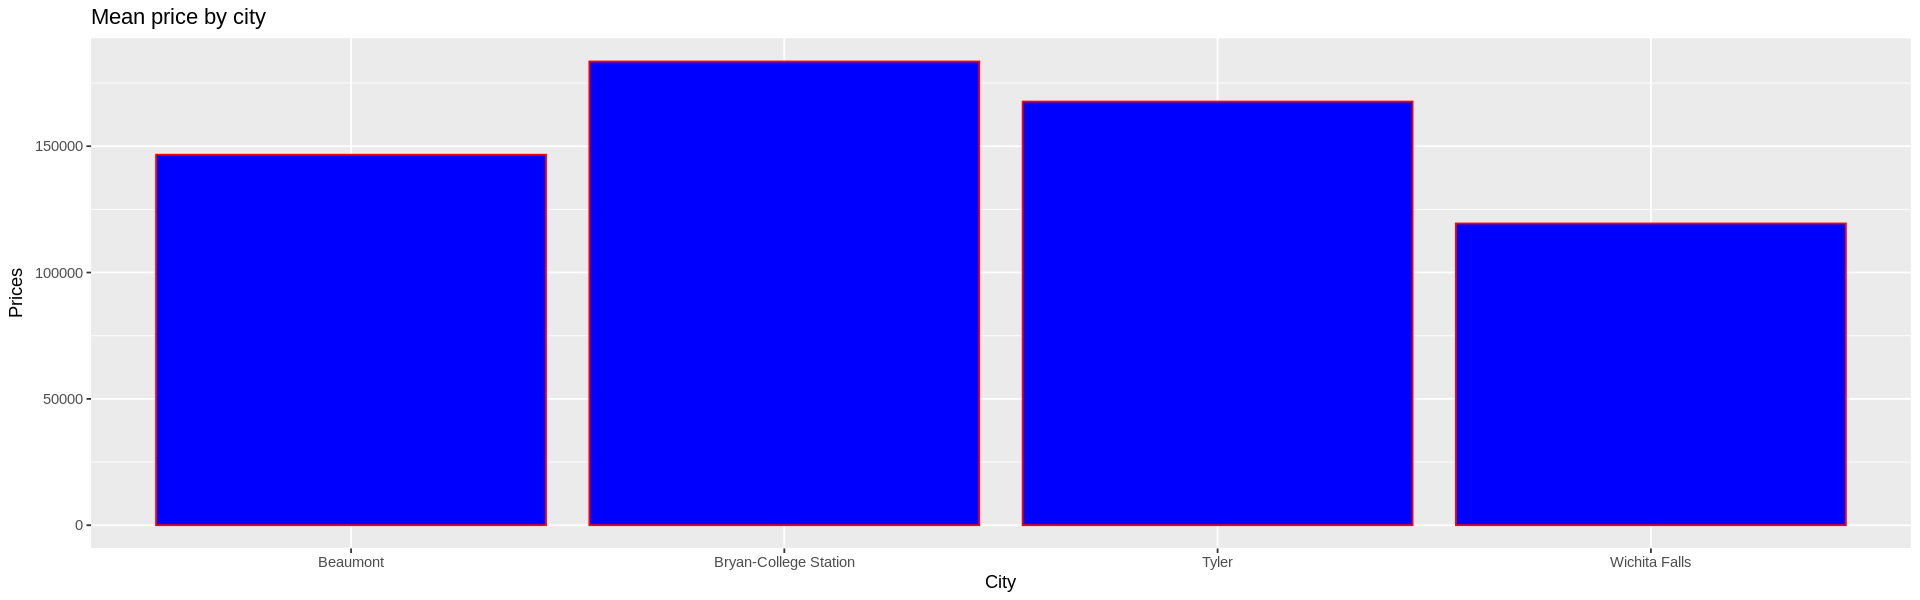

In [ ]:
# MEAN PRICE BY CITY (BAR CHART)

ggplot(data = data_avg_mean_prices_x_city) +
  geom_bar(
    aes(x = city, y = avg_mean_prices),
    stat = "identity",
    col = "red",
    fill = "blue"
  ) +
  labs(
    title = "Mean price by city",
    x = "City",
    y = "Prices"
  ) +
  scale_y_continuous(breaks = seq(0, 250000, 50000))

The highest price is the one referred to Bryan-College Station, while the lowest price is the one refered to Wichita Falls



## 6.3 Effectiveness of Sales Listings

**Request:** Try to create another column that provides an indication of the “effectiveness” of sales listings. Can you draw any conclusions?

To represent listing effectiveness, the current sales rate was calculated by dividing the number of active listings (`listings`) by the number of months required to clear the inventory (`months_inventory`).

The result represents the estimated number of listings cleared per month and therefore provides a measure of the sales rate:

v = s / t

where `s` corresponds to active listings and `t` to months of inventory.


In [ ]:
re_data$current_sales_speed <- re_data$listings / re_data$months_inventory

Un modo per provare a fare qualche considerazione come richiesto, considerando il valore informativo minimo del dato per singola riga, mi è sembrato quello di calcolare una media del ritmo di vendita condizionata alla città, in modo da poter comprendere quale sia la città con la maggior velocità media di smaltimento di inserzioni.

In [ ]:
# MEAN LISTING CLEARANCE RATE BY CITY

avg_speed_city = re_data %>%
  group_by(city) %>%
  summarise(
    average_sales_speed = mean(current_sales_speed),
    .groups = "drop"
  )

kable(
  avg_speed_city,
  caption = "Mean listing clearance rate by city",
  digits = 2
)



Table: Mean listing clearance rate by city

|city                  | average_sales_speed|
|:---------------------|-------------------:|
|Beaumont              |              172.06|
|Bryan-College Station |              199.58|
|Tyler                 |              260.98|
|Wichita Falls         |              116.74|


Wichita Falls is the city with the lowest sales speed, whereas Tyler is the city with the highest number of monthly sales.

# 7. Conditional Analysis

**Request:** Use the `dplyr` package or base R to perform conditional statistical analyses by city, year, and month. Generate summary statistics, including the mean and standard deviation, and visualize the results graphically.

The mean and standard deviation of the variables `sales` and `listings` are calculated by conditioning on `city`, `year`, and `month`.


In [ ]:
# FUNCTION FOR CONDITIONAL ANALYSIS

conditional_analysis <- function(v) {

  # Calculate mean and standard deviation for sales and listings
  df_summary <- re_data %>%
    group_by(.data[[v]]) %>%
    summarise(
      mean_sales = mean(sales),
      sales_variability = sd(sales),
      mean_listings = mean(listings),
      listings_variability = sd(listings),
      .groups = "drop"
    )

  # Summary table
  print(
    kable(
      df_summary,
      caption = paste("Mean and standard deviation conditioned on", v)
    )
  )

  # Separator
  cat("\n\n-----------------------------------------------------------------------------------------------------------------------------\n\n")

  # Sales chart
  g1 <- ggplot(df_summary) +
    geom_bar(
      aes(x = .data[[v]], y = mean_sales),
      stat = "identity",
      fill = "blue",
      col = "red"
    ) +
    geom_errorbar(
      aes(
        x = .data[[v]],
        ymin = mean_sales - sales_variability,
        ymax = mean_sales + sales_variability
      ),
      width = 0.2
    ) +
    labs(
      title = paste("Mean number of sales by", v),
      x = v,
      y = "Sales"
    )

  print(g1)

  # Listings chart
  g2 <- ggplot(df_summary) +
    geom_bar(
      aes(x = .data[[v]], y = mean_listings),
      stat = "identity",
      fill = "red",
      col = "blue"
    ) +
    geom_errorbar(
      aes(
        x = .data[[v]],
        ymin = mean_listings - listings_variability,
        ymax = mean_listings + listings_variability
      ),
      width = 0.2
    ) +
    labs(
      title = paste("Mean number of listings by", v),
      x = v,
      y = "Listings"
    )

  print(g2)
}

## 7.1 Results conditioned on `City`



Table: Mean and standard deviation conditioned on city

|city                  | mean_sales| sales_variability| mean_listings| listings_variability|
|:---------------------|----------:|-----------------:|-------------:|--------------------:|
|Beaumont              |   177.3833|          41.48395|     1679.3167|             91.13382|
|Bryan-College Station |   205.9667|          84.98374|     1458.1333|            252.52753|
|Tyler                 |   269.7500|          61.96380|     2905.0500|            226.75458|
|Wichita Falls         |   116.0667|          22.15192|      909.5833|             73.75504|


-----------------------------------------------------------------------------------------------------------------------------



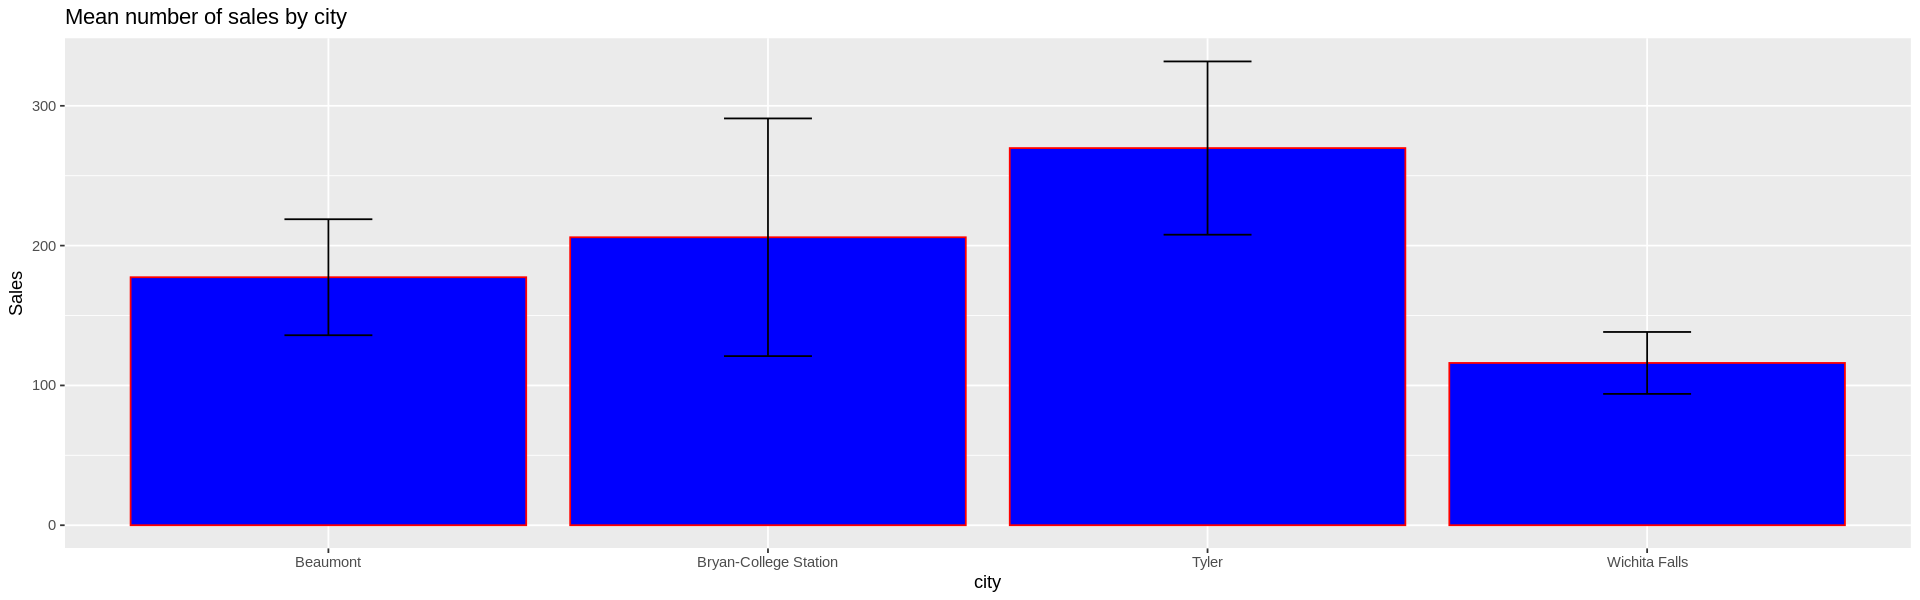

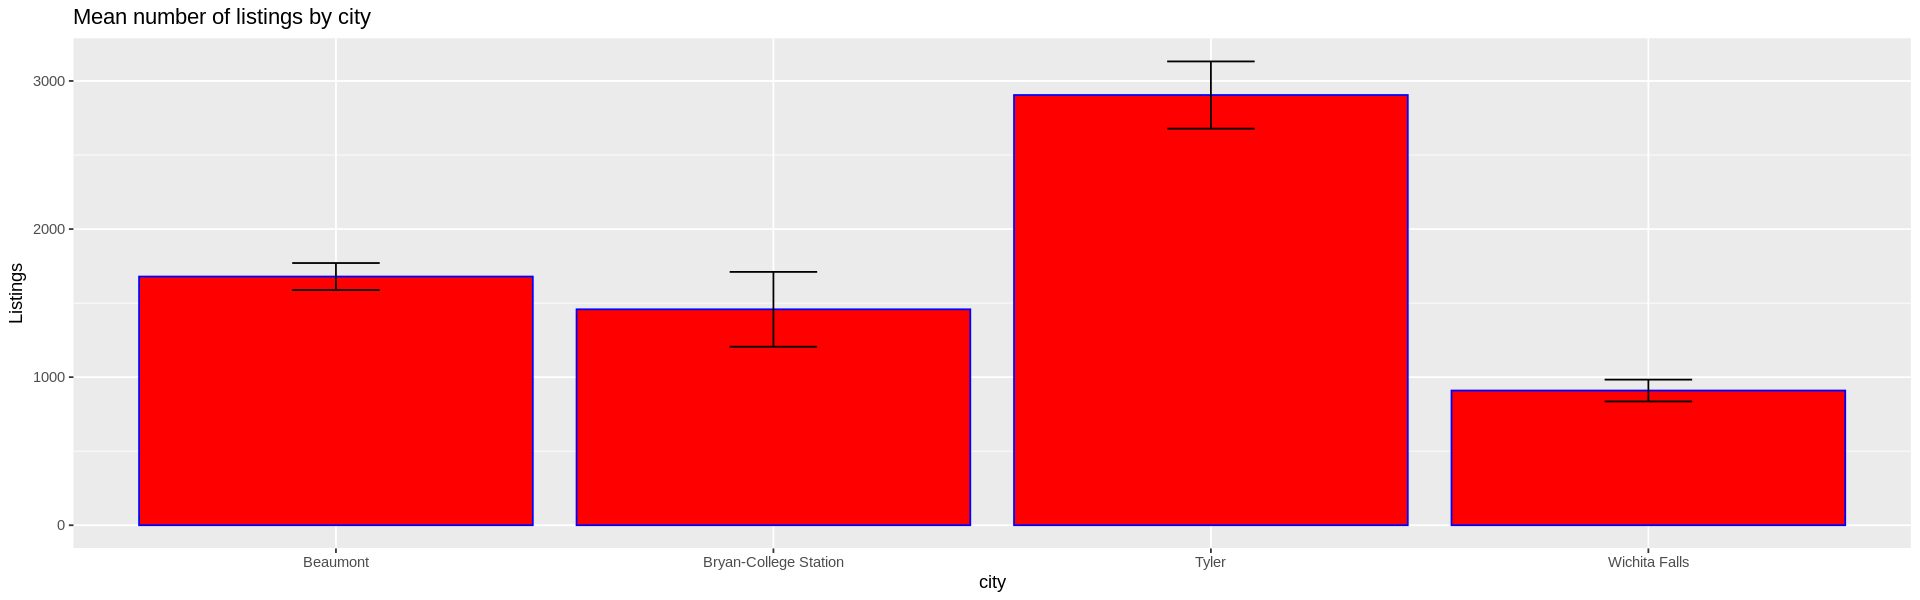

In [ ]:
conditional_analysis("city")

## 7.2 Results conditioned on `Month`



Table: Mean and standard deviation conditioned on month

| month| mean_sales| sales_variability| mean_listings| listings_variability|
|-----:|----------:|-----------------:|-------------:|--------------------:|
|     1|     127.40|          43.38372|       1647.05|             704.6140|
|     2|     140.85|          51.06783|       1692.50|             711.2004|
|     3|     189.45|          59.17812|       1756.70|             727.3546|
|     4|     211.70|          65.40489|       1825.70|             770.4287|
|     5|     238.85|          83.11582|       1823.85|             790.2234|
|     6|     243.55|          94.99832|       1833.25|             811.6288|
|     7|     235.75|          96.27421|       1821.20|             826.7196|
|     8|     231.45|          79.22883|       1786.30|             815.8664|
|     9|     182.35|          72.51807|       1748.90|             802.6563|
|    10|     179.90|          74.95395|       1710.35|             779.1649|
|    11|     156.

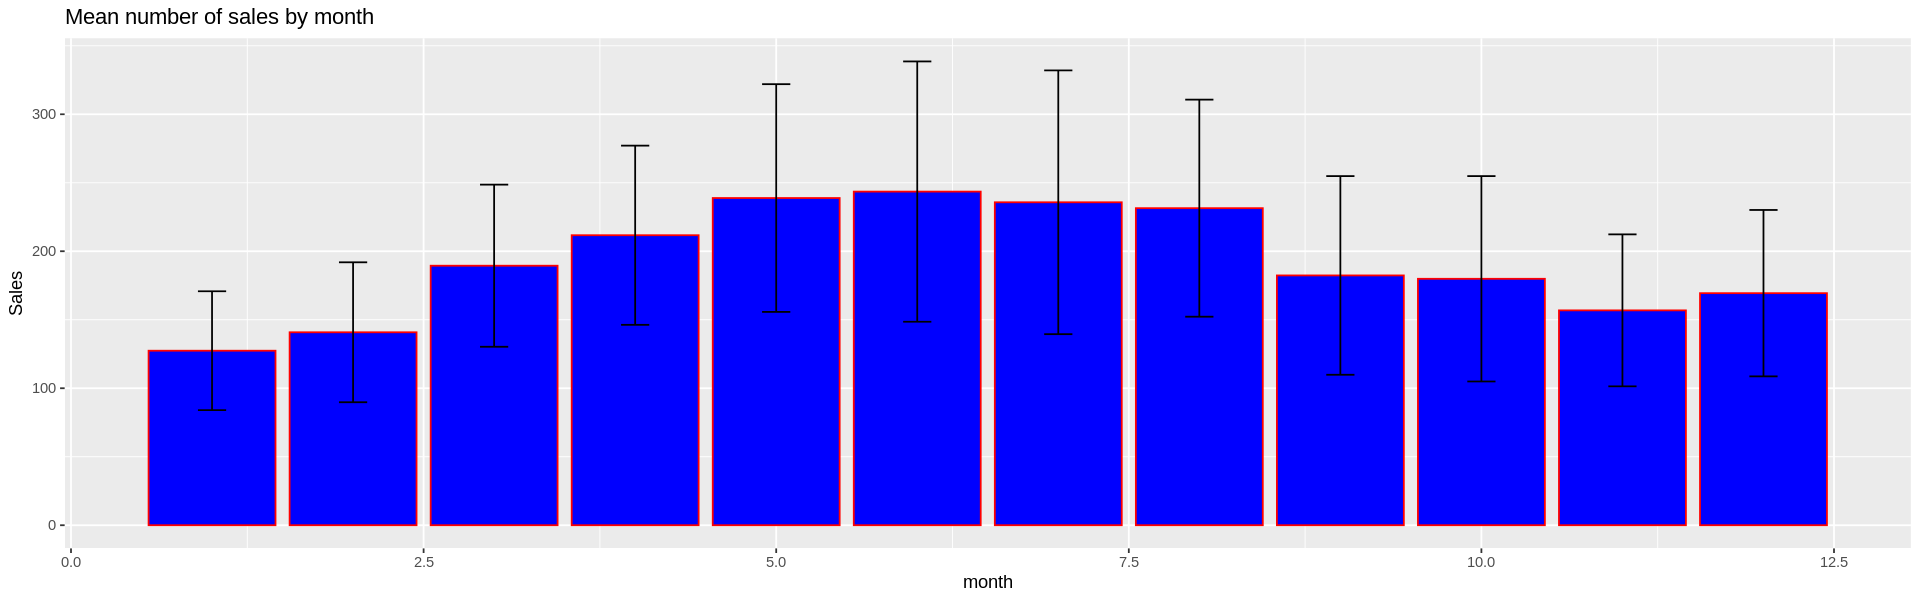

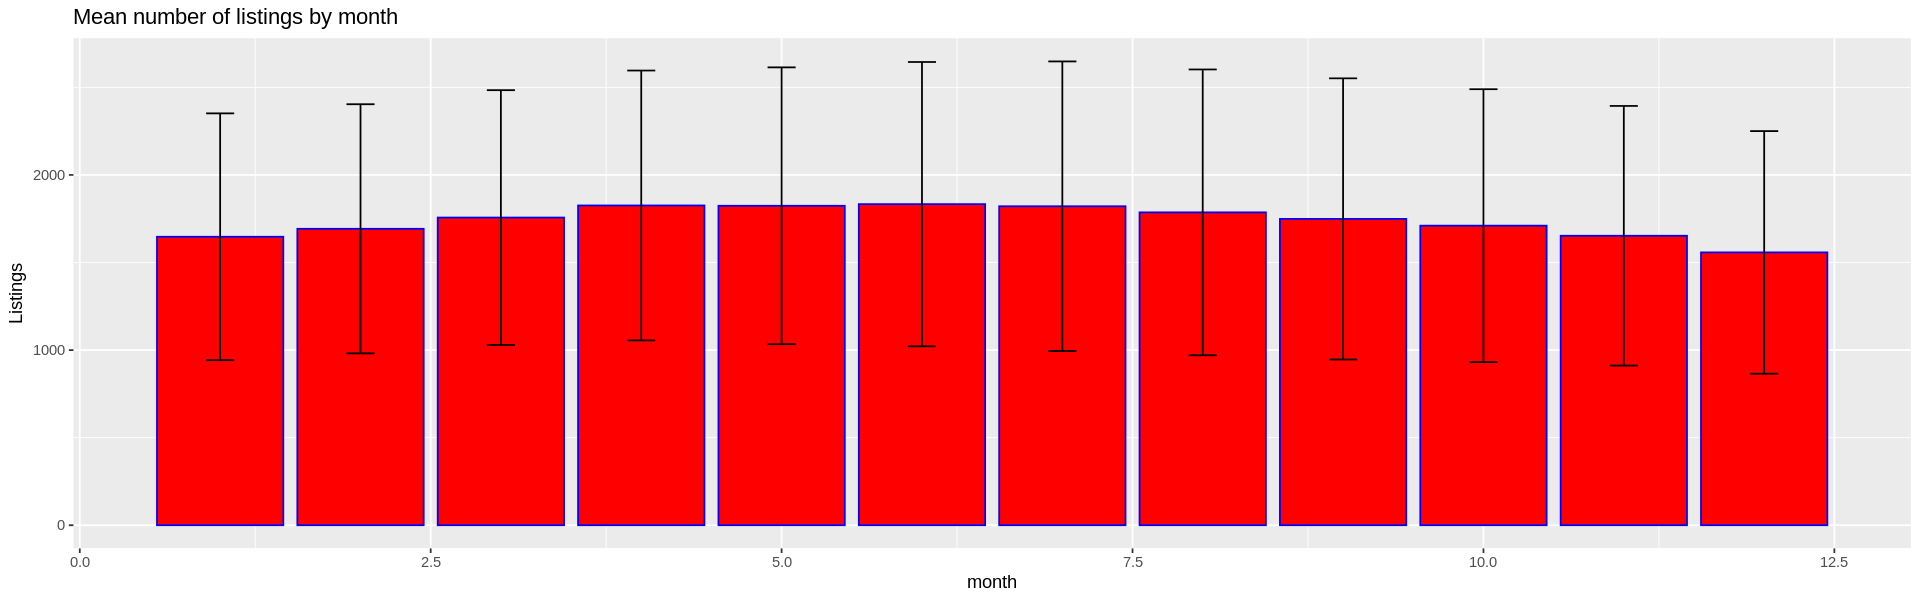

In [ ]:
conditional_analysis("month")

## 7.3 Results conditioned on `Year`



Table: Mean and standard deviation conditioned on year

| year| mean_sales| sales_variability| mean_listings| listings_variability|
|----:|----------:|-----------------:|-------------:|--------------------:|
| 2010|   168.6667|          60.53708|      1826.000|             785.0201|
| 2011|   164.1250|          63.87042|      1849.646|             780.3777|
| 2012|   186.1458|          70.90509|      1776.812|             738.4492|
| 2013|   211.9167|          83.99641|      1677.604|             743.5239|
| 2014|   230.6042|          95.51490|      1560.042|             706.7086|


-----------------------------------------------------------------------------------------------------------------------------



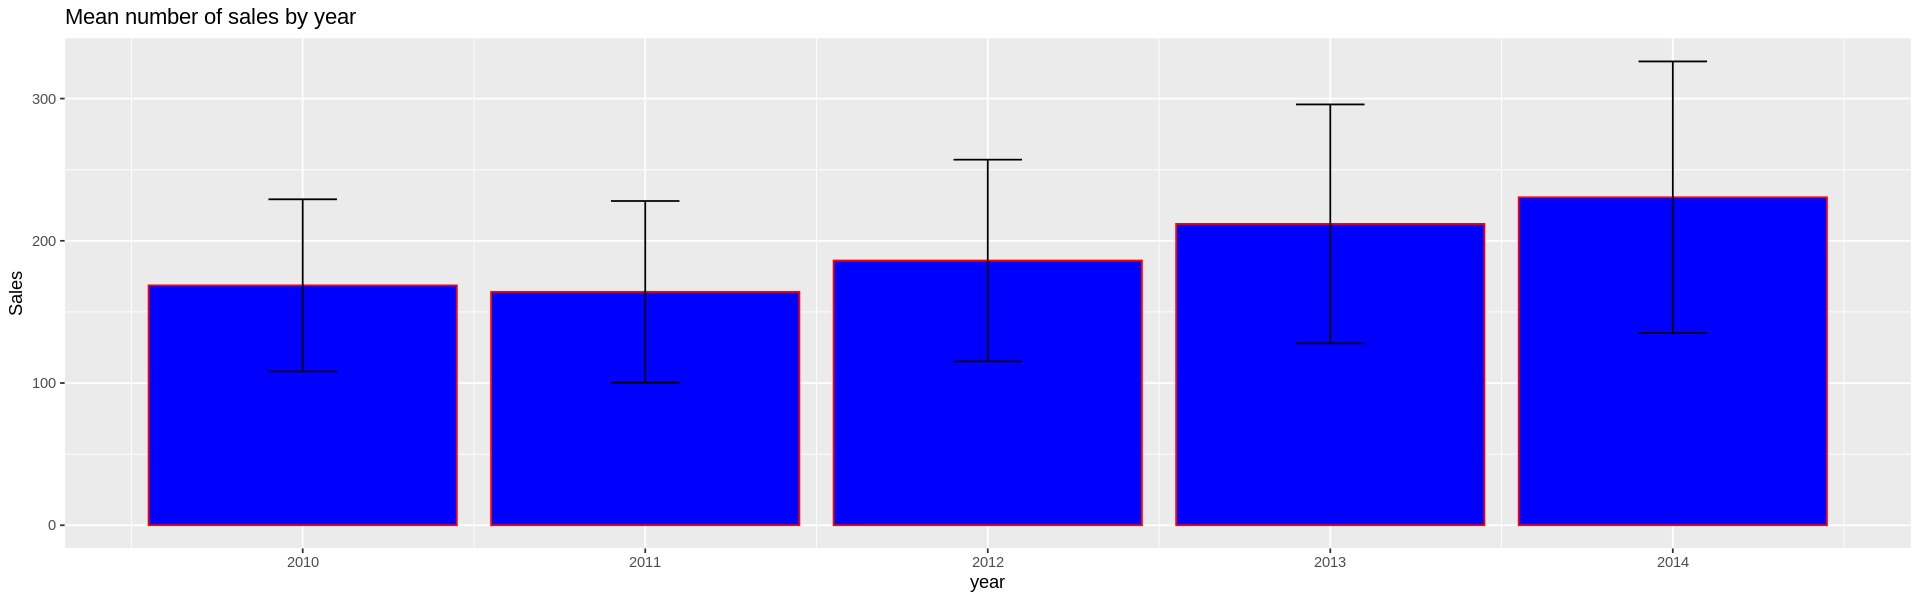

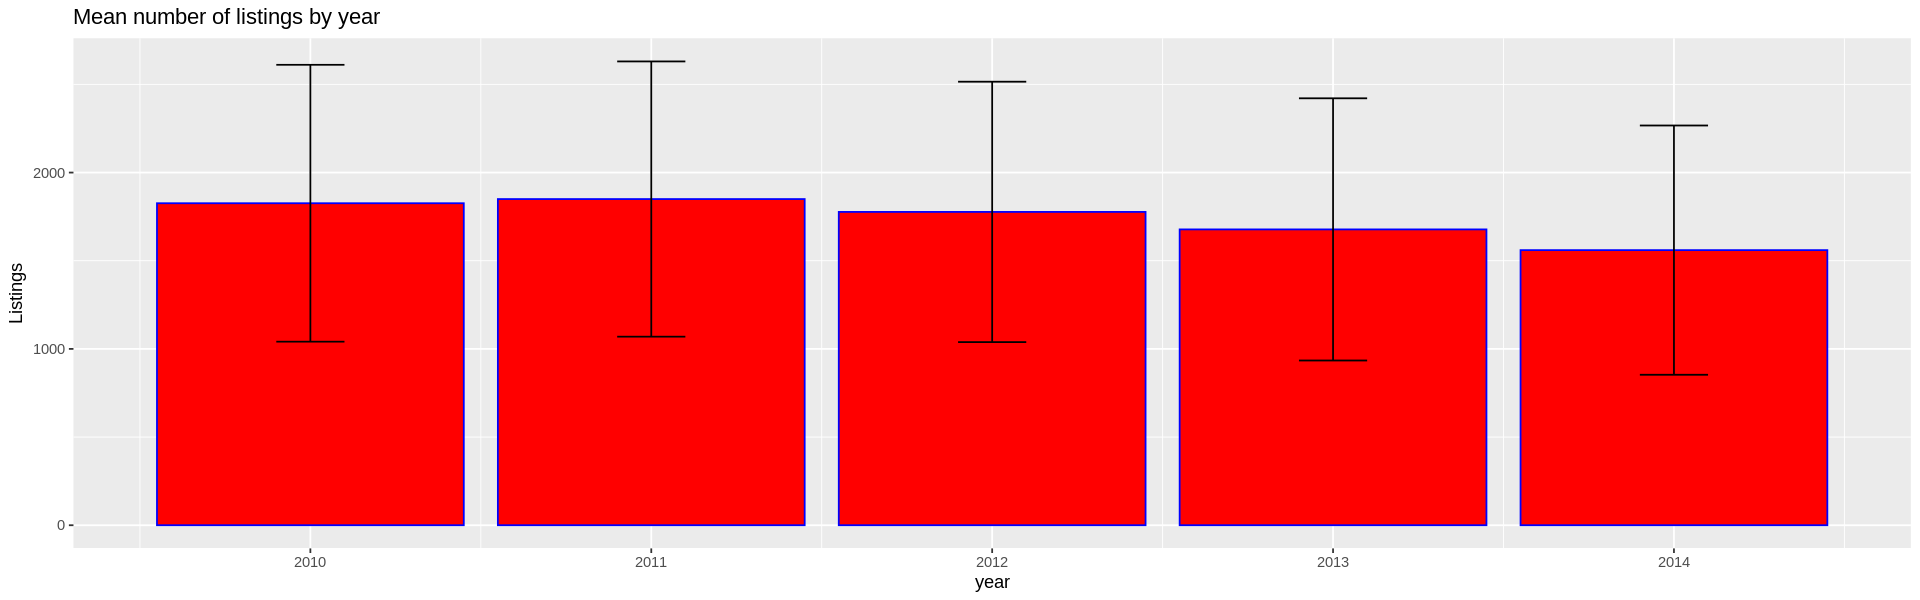

In [ ]:
conditional_analysis("year")

The charts obtained by conditioning on city suggest a positive correlation between the average number of active listings and the average number of sales, with Bryan-College Station as the only exception. Tyler has the highest average number of both listings and sales, while Wichita Falls records the lowest values for both variables.

When conditioning on month reveals a positive correlation: an increase in listings corresponds to an increase in sales, while a decrease in listings is associated with a decline in sales.

By contrast, conditioning on year, the charts show a negative correlation: during the first two years, an increase in the average number of listings corresponds to a decrease in the average number of sales; over the following three years, a decline in average listings is associated with an increase in average sales.

# 8. Create visualization with `ggplot2`

## 8.1 Median price for conditioned on `City` and `Year`

**Request:** use a boxplot to compare price distribution among cities.

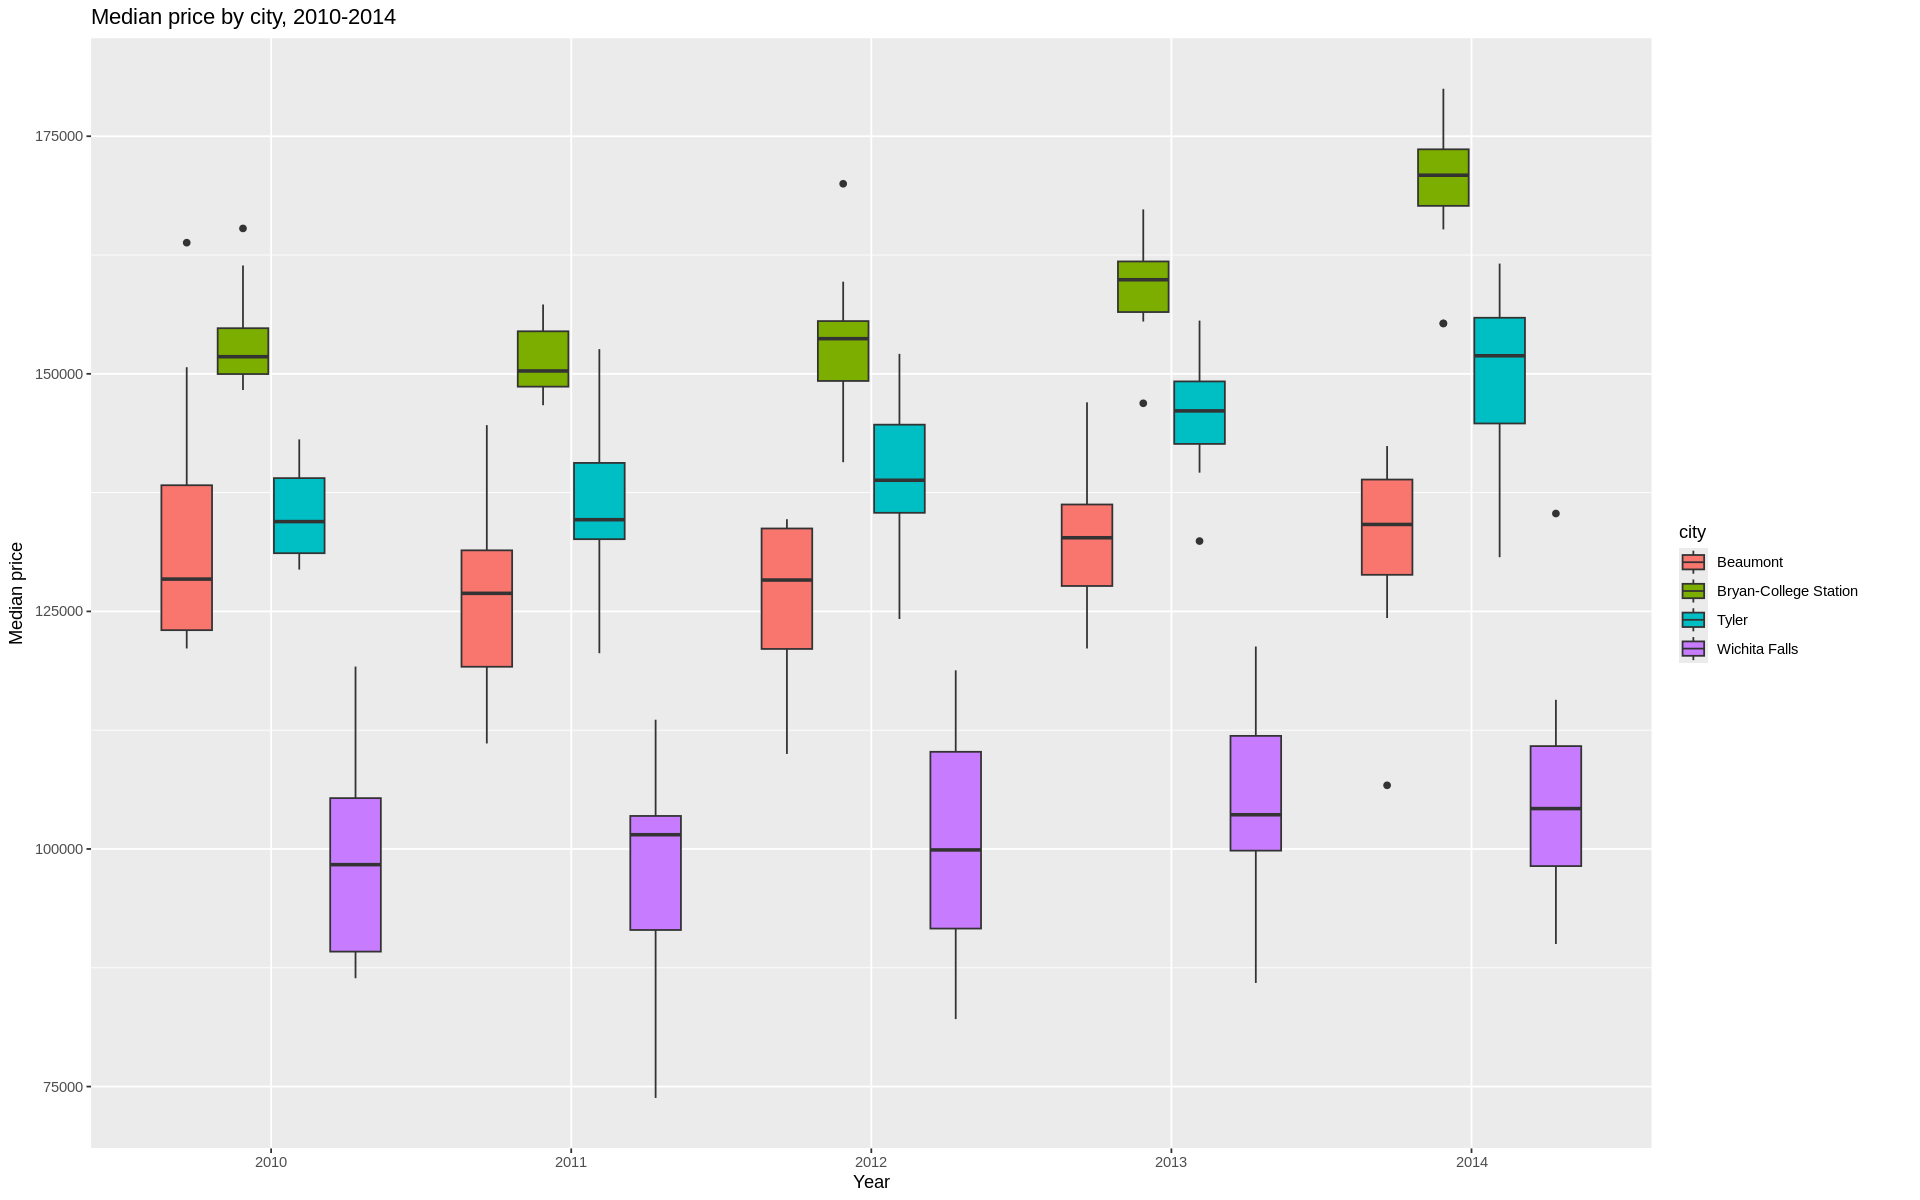

In [ ]:
# MEDIAN PRICE BY CITY (BOXPLOT)

# Set plot size
options(repr.plot.height = 10)


ggplot(data = re_data) +
  geom_boxplot(
    aes(
      x = factor(year),
      y = median_price,
      fill = city
    )
  ) +
  labs(
    x = "Year",
    y = "Median price",
    title = "Median price by city, 2010-2014"
  )

Wichita Falls exhibits the lowest median prices and shows a stable pattern over time. Bryan-College Station, by contrast, records the highest median prices and displays a clearly increasing trend over the five-year period.

In terms of variability, Bryan-College Station is the most stable city: both the box size and whisker length indicate limited variability. Wichita Falls, on the other hand, tends to show larger boxes and longer whiskers on average.

Overall, Beaumont, Tyler, and Bryan-College Station show broadly similar patterns over time, although at different levels and with different intensities. Wichita Falls displays a more stable trend and remains at the lowest level. The chart is consistent with the mean price distribution by city shown in Request 6.

## 8.2 Total Volume contidioned on `City` and `Month`

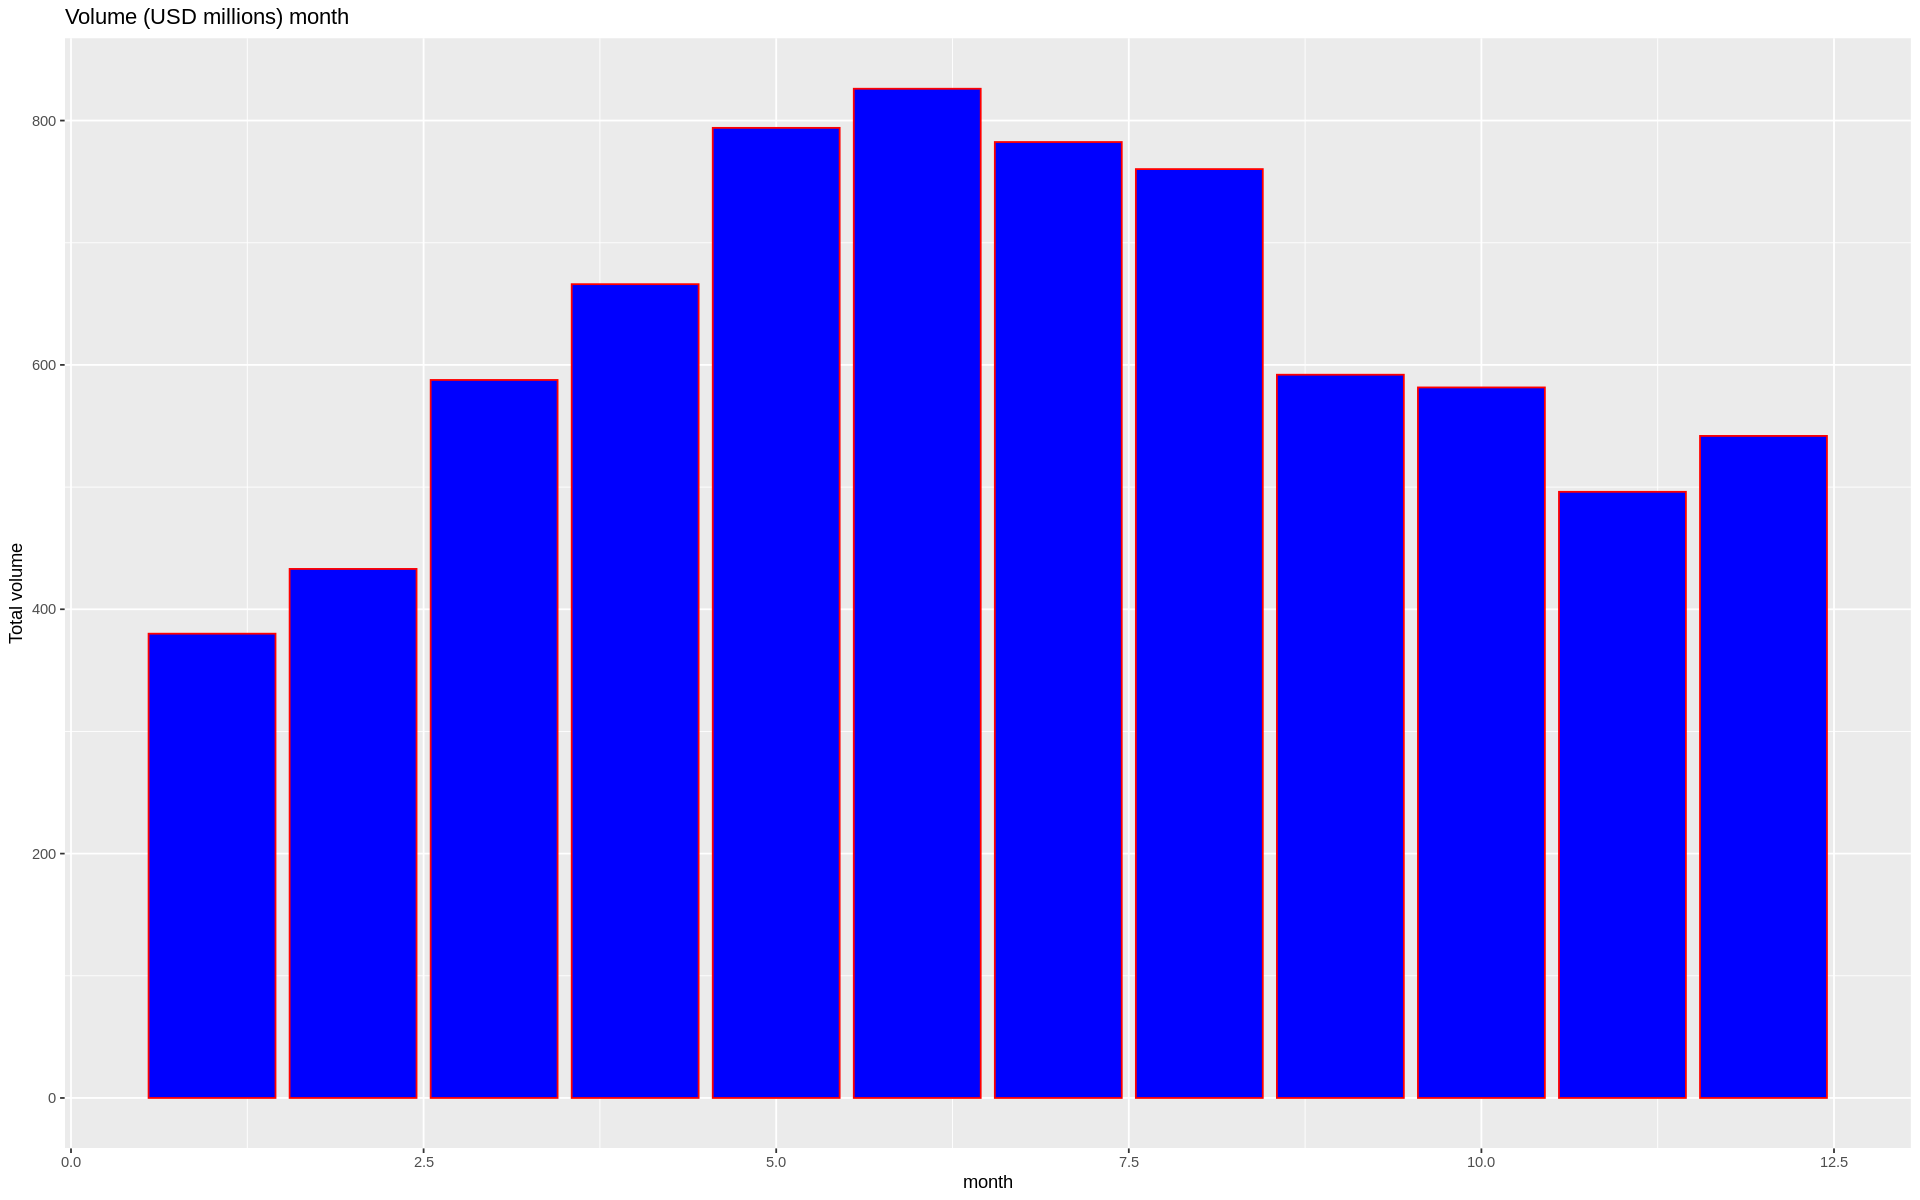

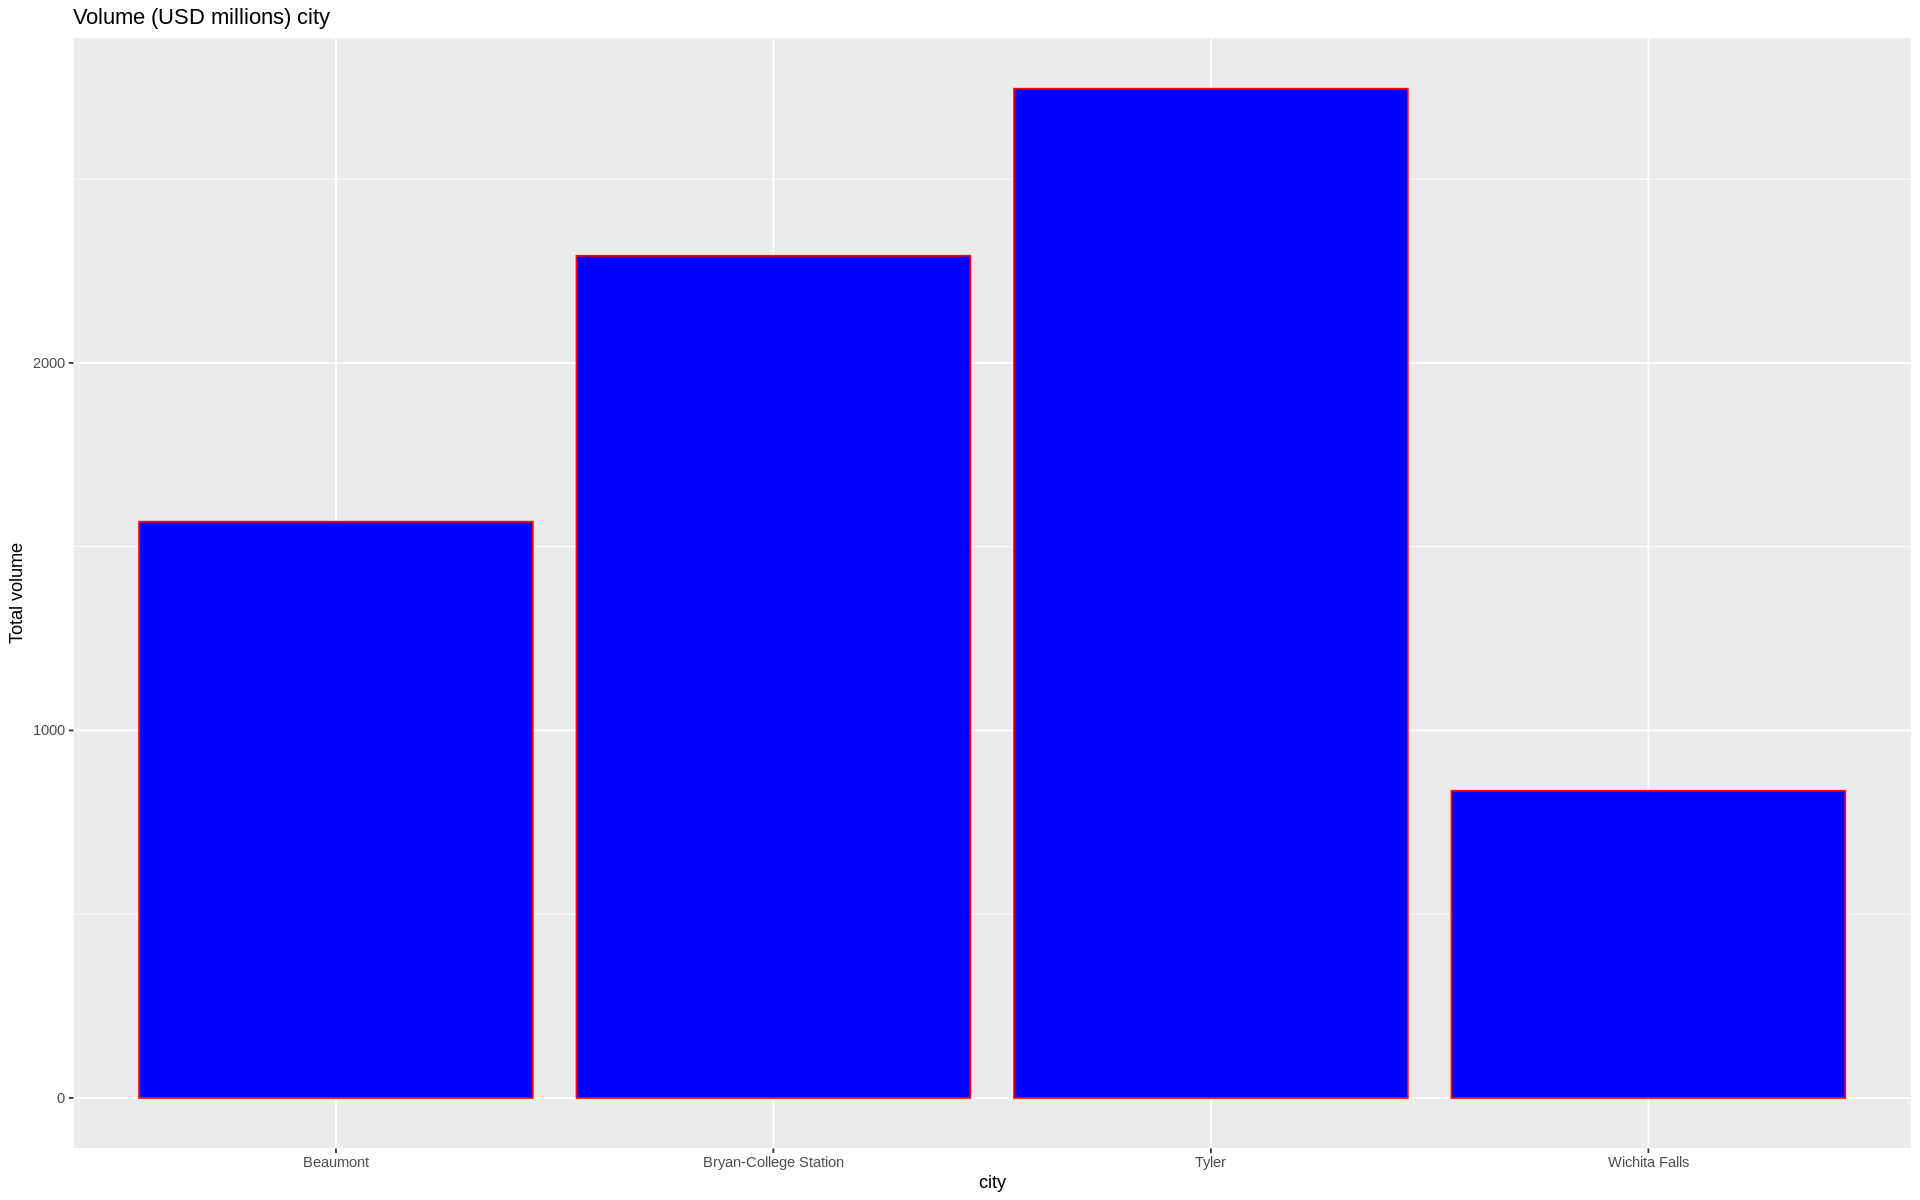

In [ ]:
# Create a vector with the variables of interest
vars <- c("month", "city")

for (v in vars) {
  df_summary <- re_data %>%
    group_by(.data[[v]]) %>%
    summarise(
      total_volume = sum(volume),
      .groups = "drop"
    )

  kable(
    df_summary,
    caption = paste("Total volume by", v)
  )

  # Total sales volume chart
  print(
    ggplot(df_summary) +
      geom_col(
        aes(x = .data[[v]], y = total_volume),
        col = "red",
        fill = "blue"
      ) +
      labs(
        title = paste("Volume (USD millions)", v),
        x = v,
        y = "Total volume"
      )
  )
}

The plot of total volume conditioned on month reflects the same trend observed for the mean sales of request 7, computed wrt the same variable, and shows peaks in sales volume between March and August.

Tyler is the city with the highest total sales volume, while Wichita Falls has the lowest. This chart is also consistent with the average number of sales shown in Request 7.

## 8.3 Line chart for total annual sales

In [ ]:
# SALES X YEAR

dati_salesXyear = re_data %>%
  group_by(year) %>%
  summarise(
    yearly_sales = sum(sales),
    .groups = "drop"
  )

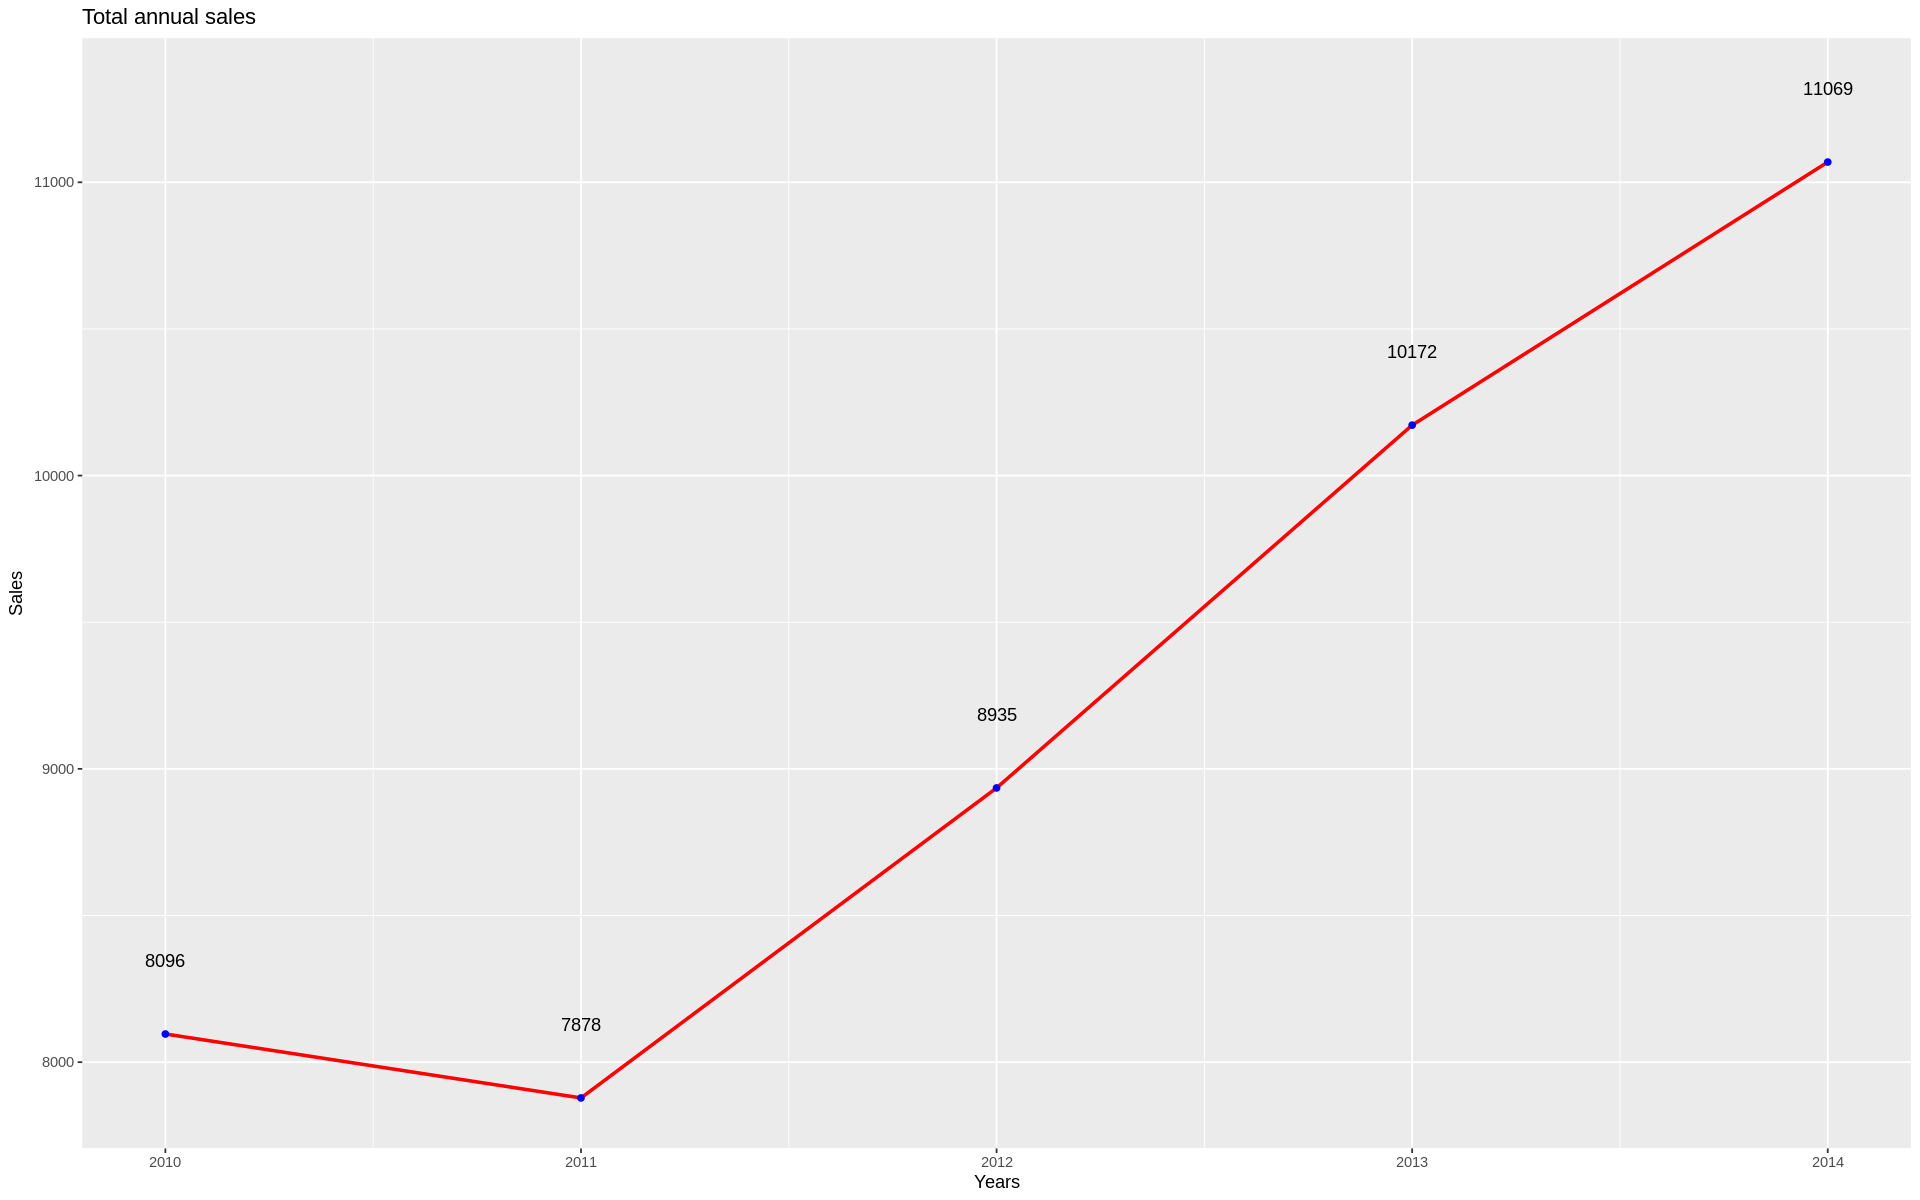

In [ ]:
# LINE CHART COMPARING SALES TRENDS ACROSS DIFFERENT TIME PERIODS

ggplot(data = dati_salesXyear) +
  geom_line(
    aes(x = year, y = yearly_sales),
    col = "red",
    lwd = 1
  ) +
  geom_point(
    aes(x = year, y = yearly_sales),
    col = "blue"
  ) +
  labs(
    x = "Years",
    y = "Sales",
    title = "Total annual sales"
  ) +
  geom_text(
    aes(
      x = year,
      y = yearly_sales + 250,
      label = yearly_sales
    )
  )

Il grafico mostra lo stesso andamento riscontrato nel grafico a barre relativo al numero medio di vendite annuali della richiesta 7: si osserva una diminuzione dal 2010 al 2011 e una crescita negli anni successivi.
The graph exhibits the same pattern of the bar chart of the annual mean sales in request 7: there a decline between 2010 and 2011 and an increase in following years.

## Line chart for each city

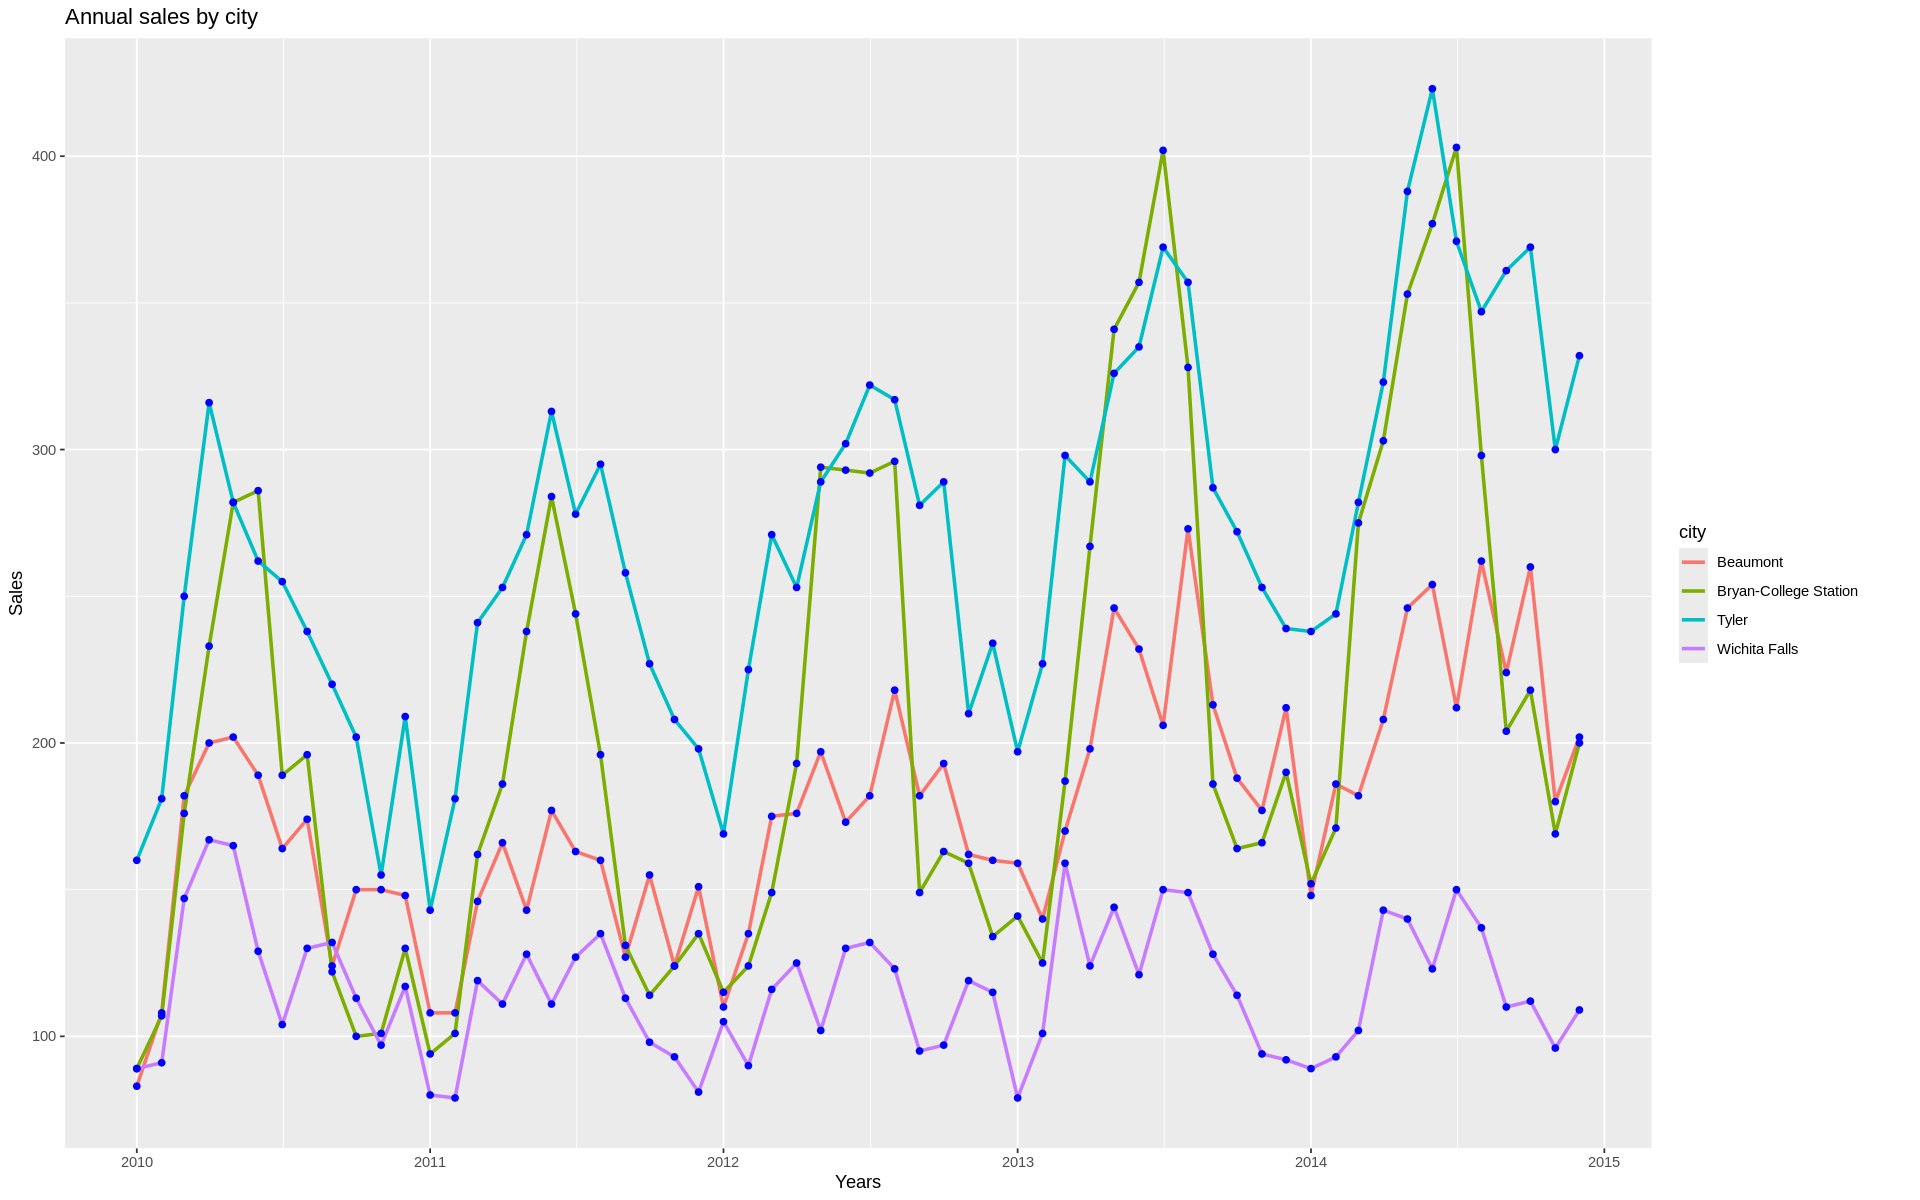

In [ ]:
# LINE CHART COMPARING SALES TRENDS BY CITY ACROSS DIFFERENT TIME PERIODS


re_data$date = as.Date(
  paste(re_data$year, re_data$month, "01", sep = "-")
)

ggplot(data = re_data) +
  geom_line(
    aes(x = date, y = sales, col = city),
    lwd = 1
  ) +
  geom_point(
    aes(x = date, y = sales),
    col = "blue"
  ) +
  labs(
    x = "Years",
    y = "Sales",
    title = "Annual sales by city"
  ) +
  scale_x_date(
    date_breaks = "1 year",
    date_labels = "%Y"
  )

The graph shows an increasing trend for all cities but W. Falls. This city exhibits a stagnation.

Tyler has the highest number of sales and outperforms B-C Station despite having lower mean and median prices.

# 9. Operational Observations

**Request:** Use boxplots or a similar visualization to compare the distribution of total sales value across the different cities and across the different years. Are there any observations that can be made?

## 9.1 Sales volume by city

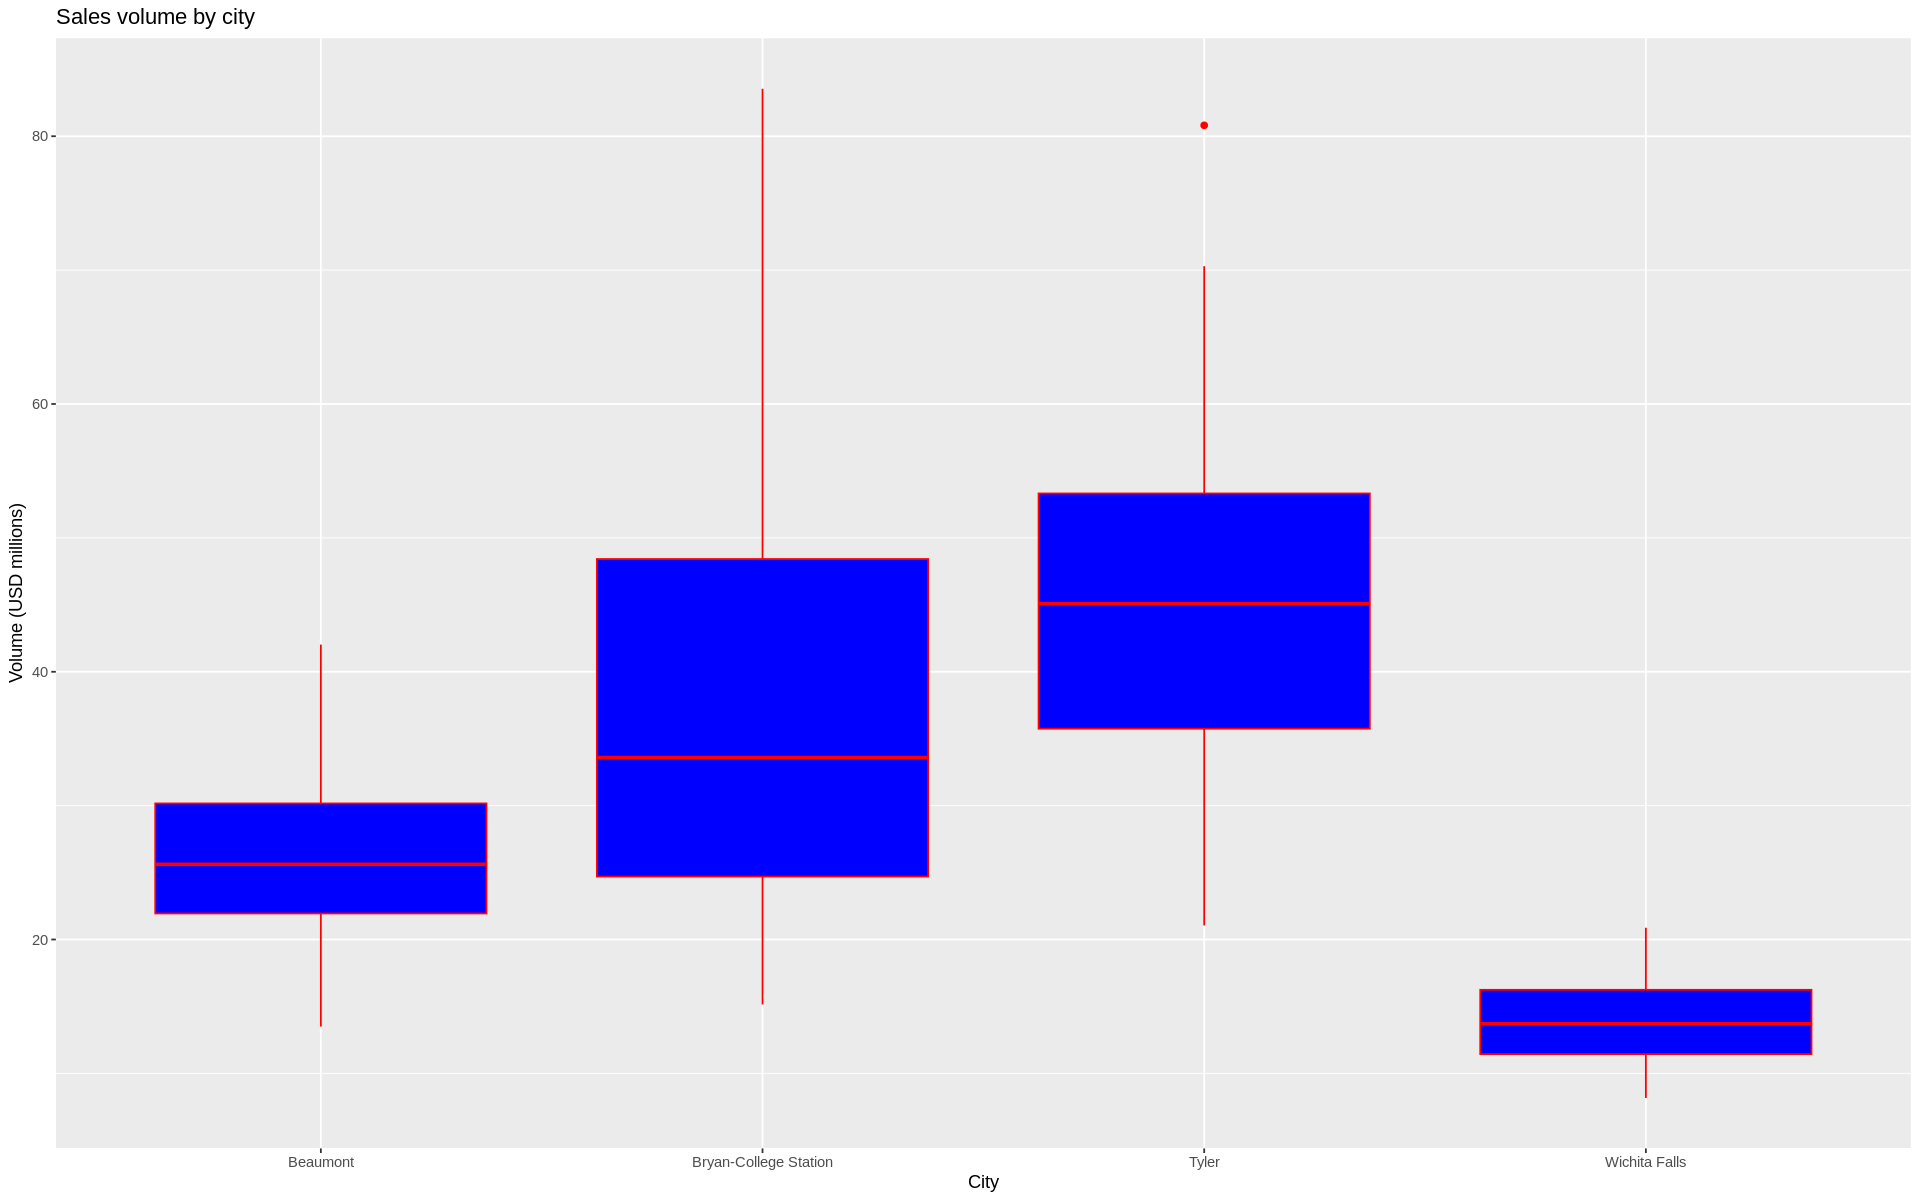

In [ ]:
# SALES VOLUME BY CITY

ggplot(data = re_data) +
  geom_boxplot(
    aes(x = city, y = volume),
    color = "red",
    fill = "blue"
  ) +
  labs(
    x = "City",
    y = "Volume (USD millions)",
    title = "Sales volume by city"
  )

The chart shows the highest degree of skewness for Bryan-College Station.

For Beaumont and Wichita Falls, the relative position remains the same as in the median price boxplot; for Bryan-College Station and Tyler, however, the positions are reversed.

The pattern shown by the boxplot is consistent with both the total number and the average number of sales by city. Wichita Falls and Beaumont therefore record the lowest sales volumes.

For Tyler, the lower median price compared with Bryan-College Station is more than offset by the higher number of sales, resulting in a higher median sales volume.

Bryan-College Station shows the highest skewness and the greatest variability, given biggest boxes and the longest whiskers.

## 9.2 Sales volume by Year

In [ ]:
ggplot(data = re_data) +
  geom_boxplot(
    aes(
      x = factor(year),
      y = volume,
      group = year
    ),
    color = "red",
    fill = "blue"
  ) +
  labs(
    x = "Year",
    y = "Volume (USD millions)",
    title = "Sales volume by year"
  )

The graps is consistent with the line chart in request 8

## 9.3 Monthly sales by city: stacked bar chart

In [ ]:
# MONTHLY SALES BY CITY

total_monthly_salesxcity = re_data %>%
  group_by(month, city) %>%
  summarise(
    total_monthly_sales = sum(sales),
    .groups = "drop"
  )

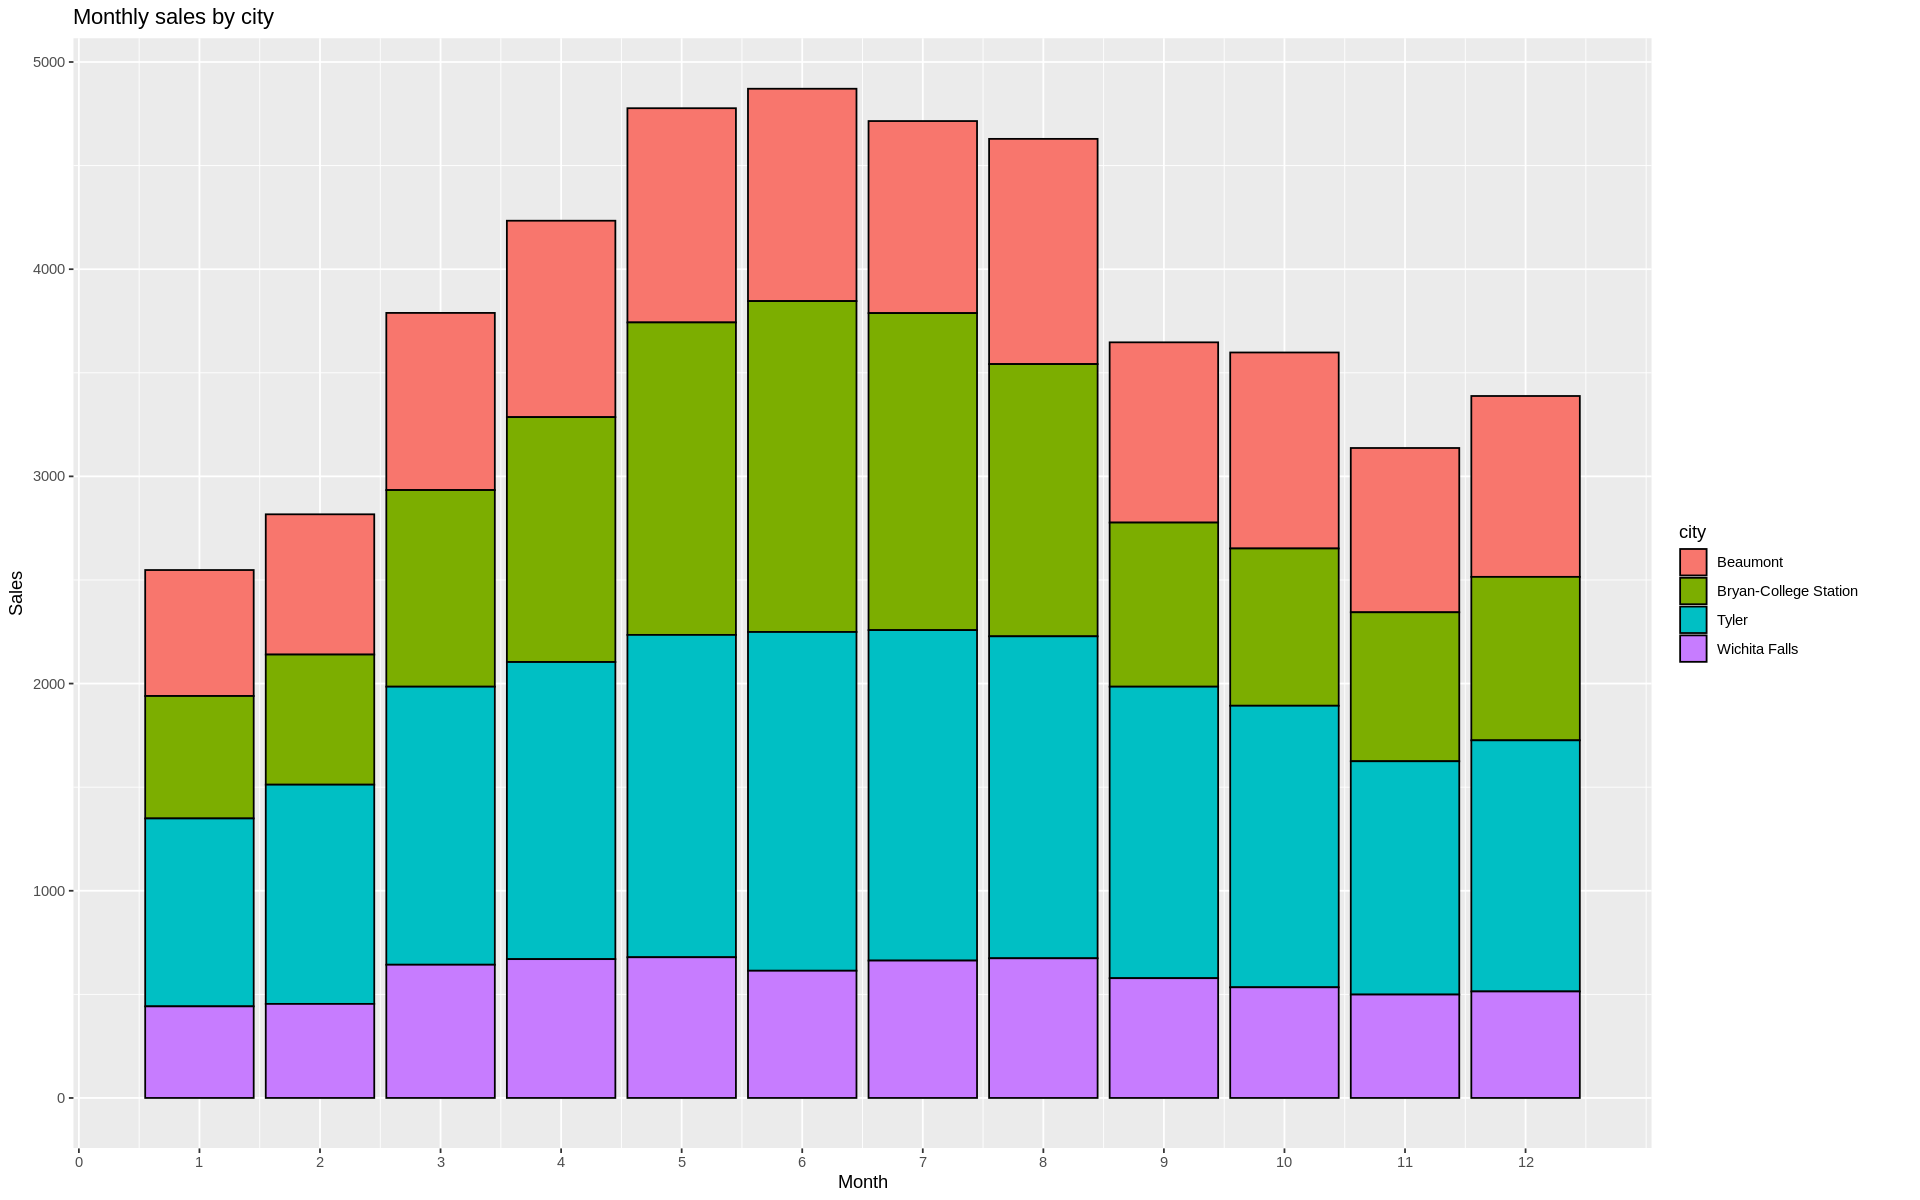

In [ ]:
# STACKED BAR CHART

ggplot(data = total_monthly_salesxcity) +
  geom_col(
    aes(
      x = month,
      y = total_monthly_sales,
      fill = city
    ),
    position = "stack",
    color = "black"
  ) +
  labs(
    x = "Month",
    y = "Sales",
    title = "Monthly sales by city"
  ) +
  scale_y_continuous(breaks = seq(0, 5000, 1000)) +
  scale_x_continuous(breaks = seq(0, 12, 1))

The monthly share for each city is obtained by summing the sales recorded in the same month across all five years in the dataset. For example, the January share for Wichita Falls is the sum of all sales recorded in January from 2010 to 2014.

For Tyler, and especially for Bryan-College Station, the middle months of the year, from March to August, are those with the highest number of sales.

For Beaumont and Wichita Falls, by contrast, the level of sales remains relatively stable throughout the year.

## 9.3.1 Normalized Graph

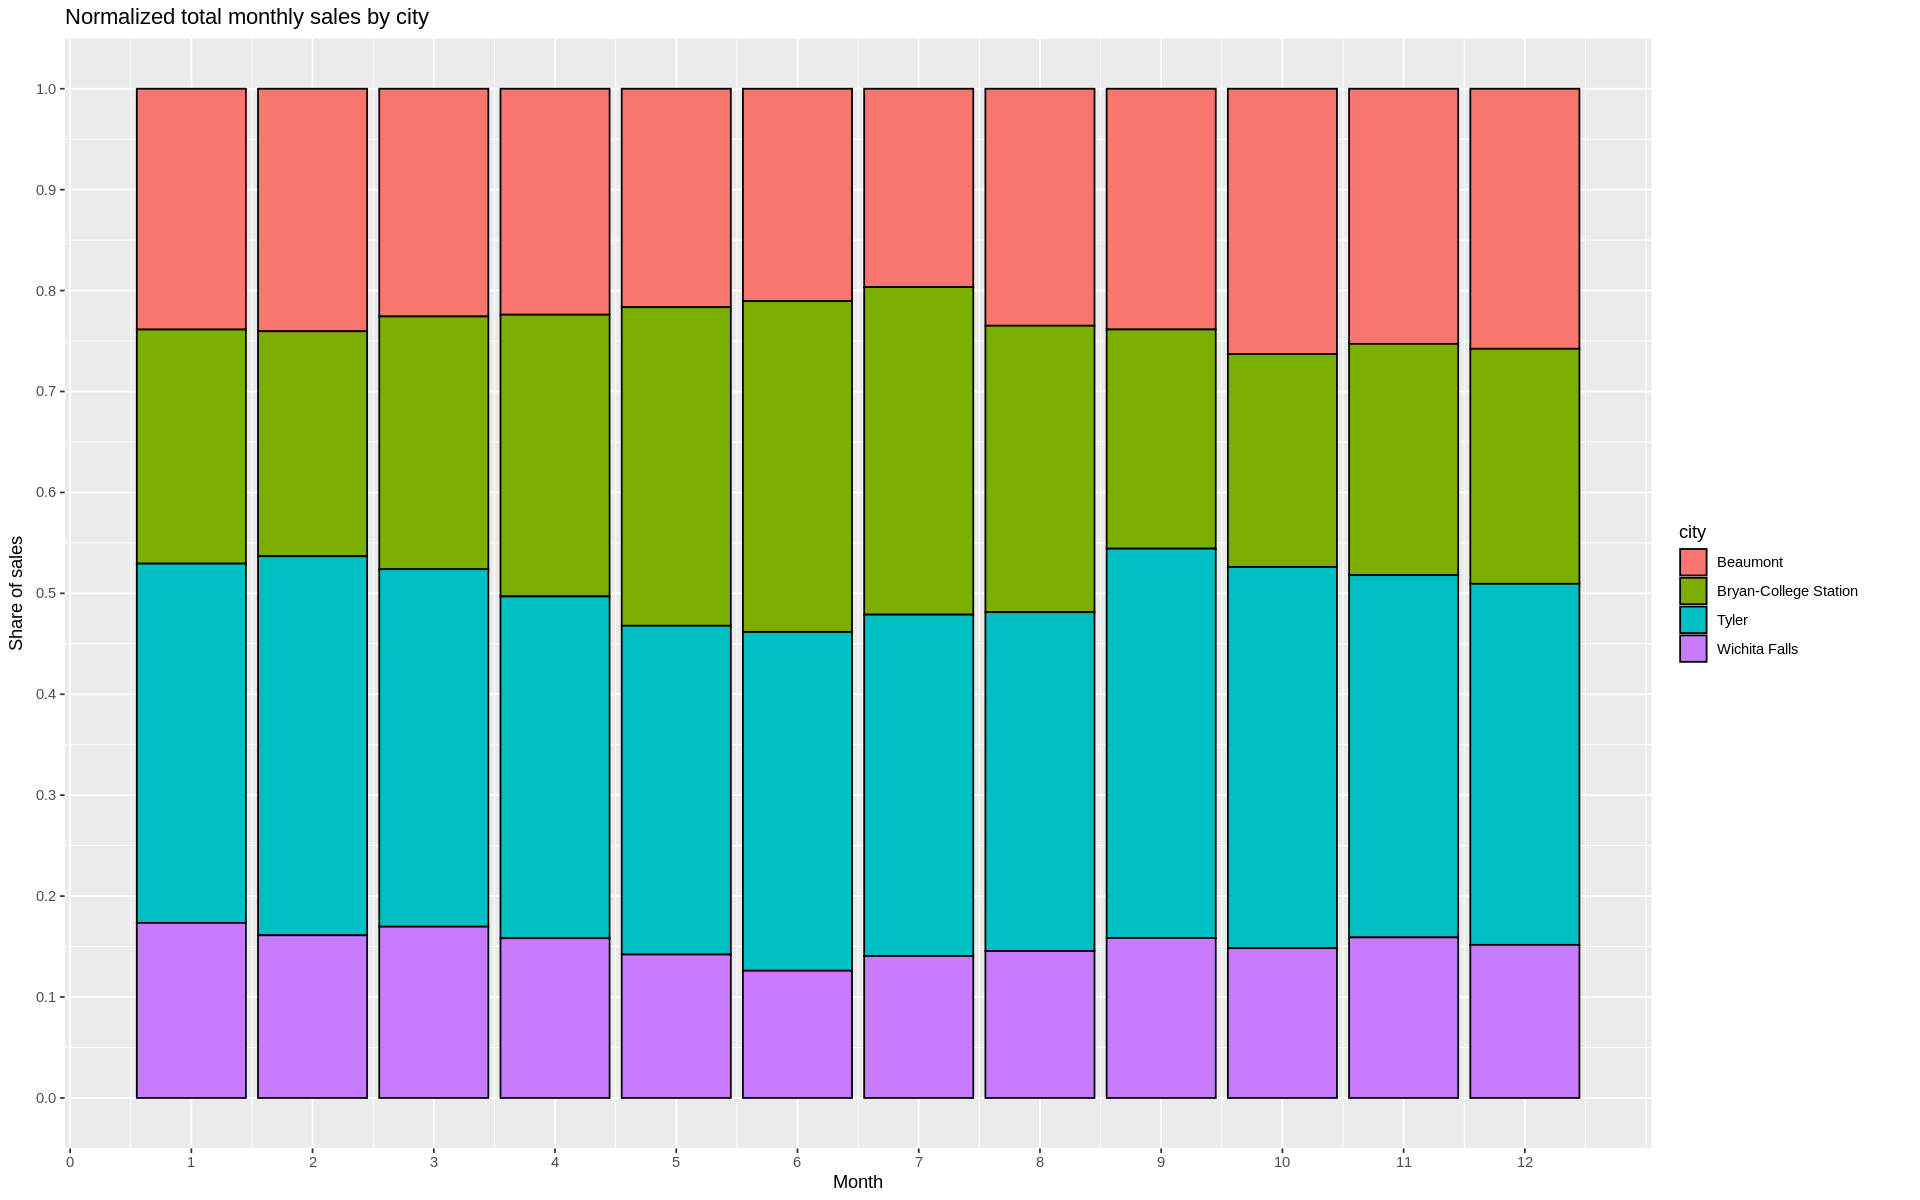

In [ ]:
ggplot(data = total_monthly_salesxcity) +
  geom_col(
    aes(
      x = month,
      y = total_monthly_sales,
      fill = city
    ),
    position = "fill",
    color = "black"
  ) +
  labs(
    x = "Month",
    y = "Share of sales",
    title = "Normalized total monthly sales by city"
  ) +
  scale_y_continuous(breaks = seq(0, 1, 0.1)) +
  scale_x_continuous(breaks = seq(0, 12, 1))

## 9.3.2 Visualization by city

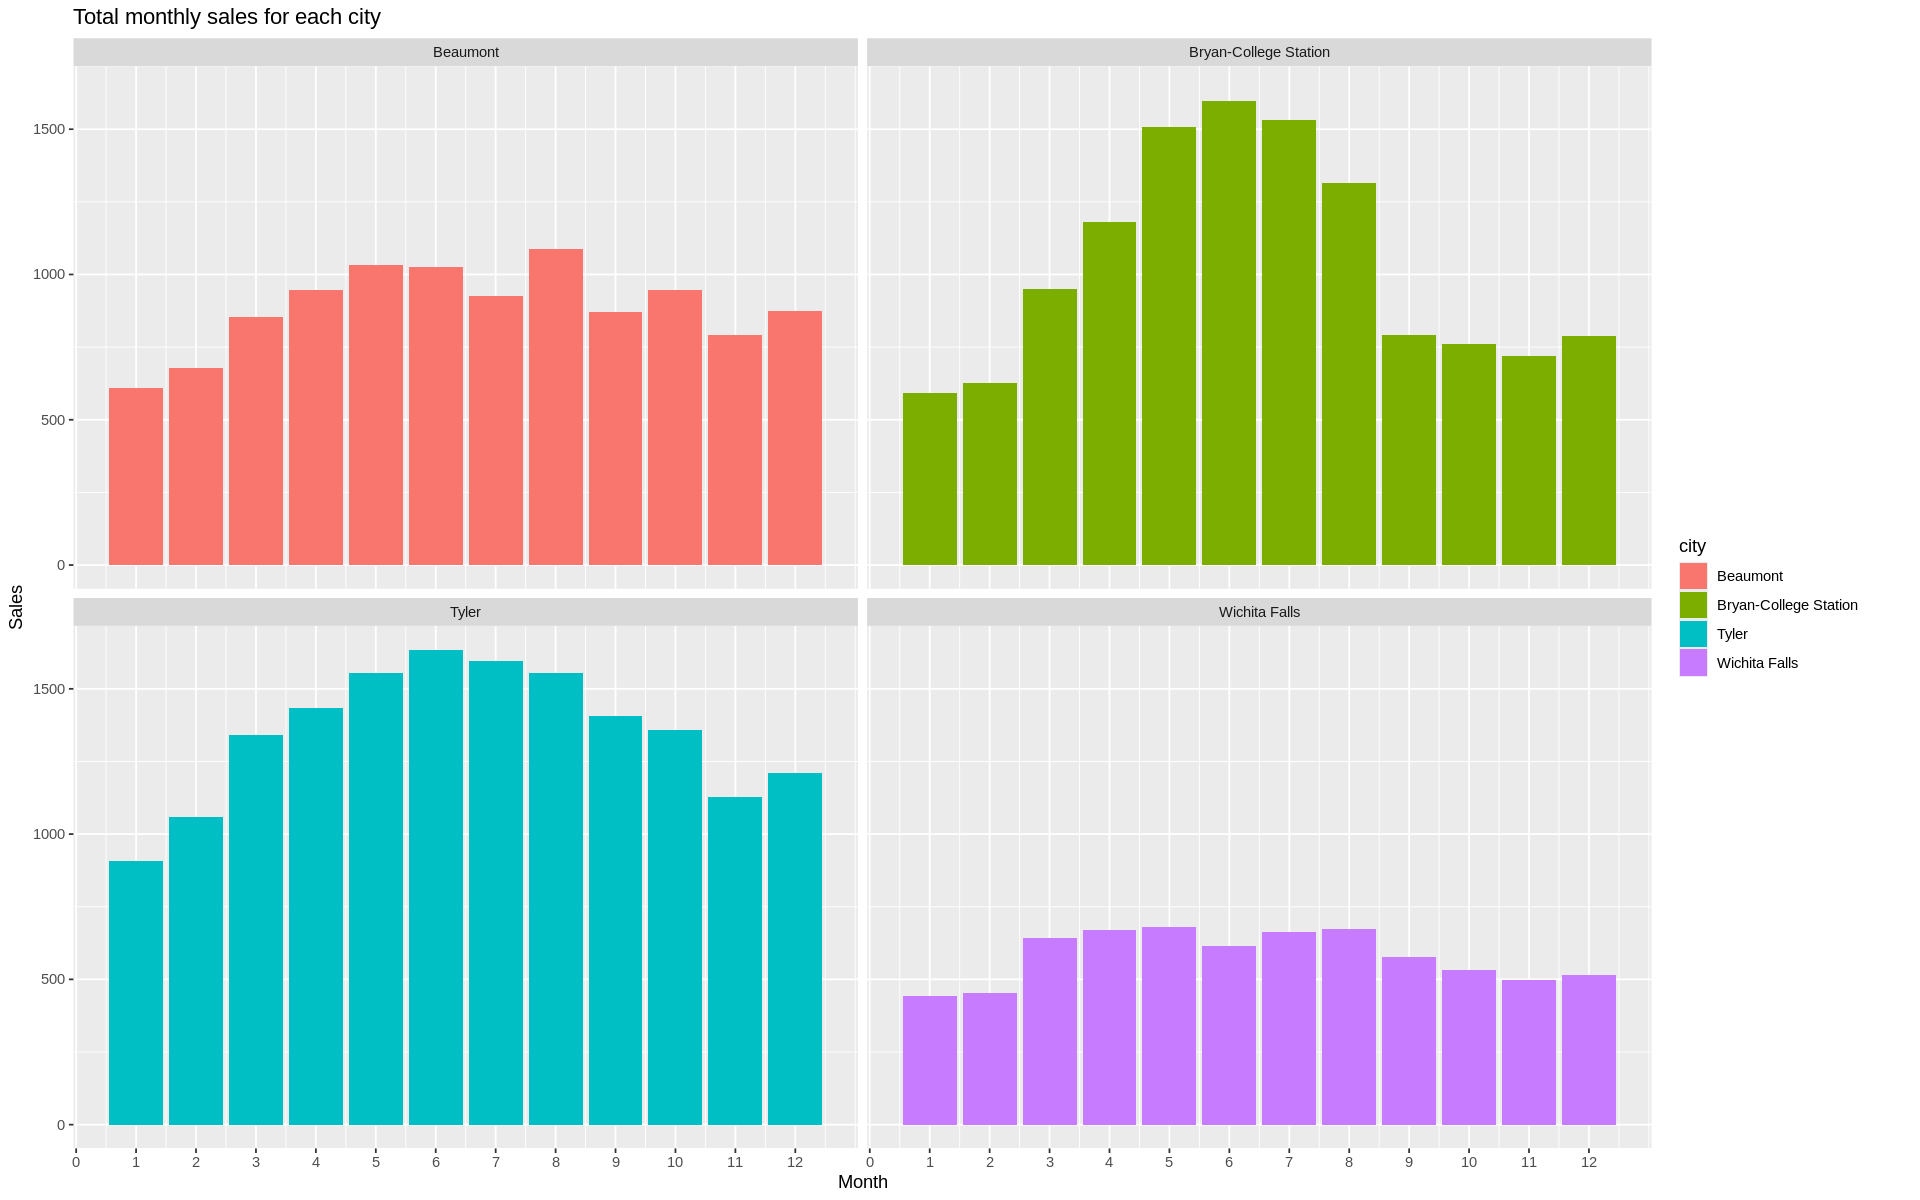

In [ ]:
ggplot(data = total_monthly_salesxcity) +
  geom_col(
    aes(
      x = month,
      y = total_monthly_sales,
      fill = city
    ),
    position = "stack"
  ) +
  labs(
    x = "Month",
    y = "Sales",
    title = "Total monthly sales for each city"
  ) +
  scale_y_continuous(breaks = seq(0, 2000, 500)) +
  scale_x_continuous(breaks = seq(0, 12, 1)) +
  facet_wrap(~ city)

This chart makes the pattern shown in the first chart of the section even more apparent. The trend is less pronounced for Tyler, which continues to record a high number of sales even in the months following August. It is also less pronounced for the lower-performing cities, although it is still present; in particular, it is more evident for Beaumont than for Wichita Falls.

## 9.4 Annual sales by city: line chart

**Request:** Try to create a line chart using a variable of your choice to make and discuss comparisons across cities and historical periods.

**Selected variable:** `sales`.


In [ ]:
# DATAFRAME FOR ANNUAL SALES LINE CHART BY CITY

 dataxlineachart = re_data %>%
   group_by(year, city) %>%
   summarise(vendite = sum(sales), .groups = "drop") %>%
   pivot_wider(names_from = city, values_from = vendite) %>%
   rename(
     Anno = year,
     Bryan_College_Station = `Bryan-College Station`,
     Wichita_Falls = `Wichita Falls`
   )

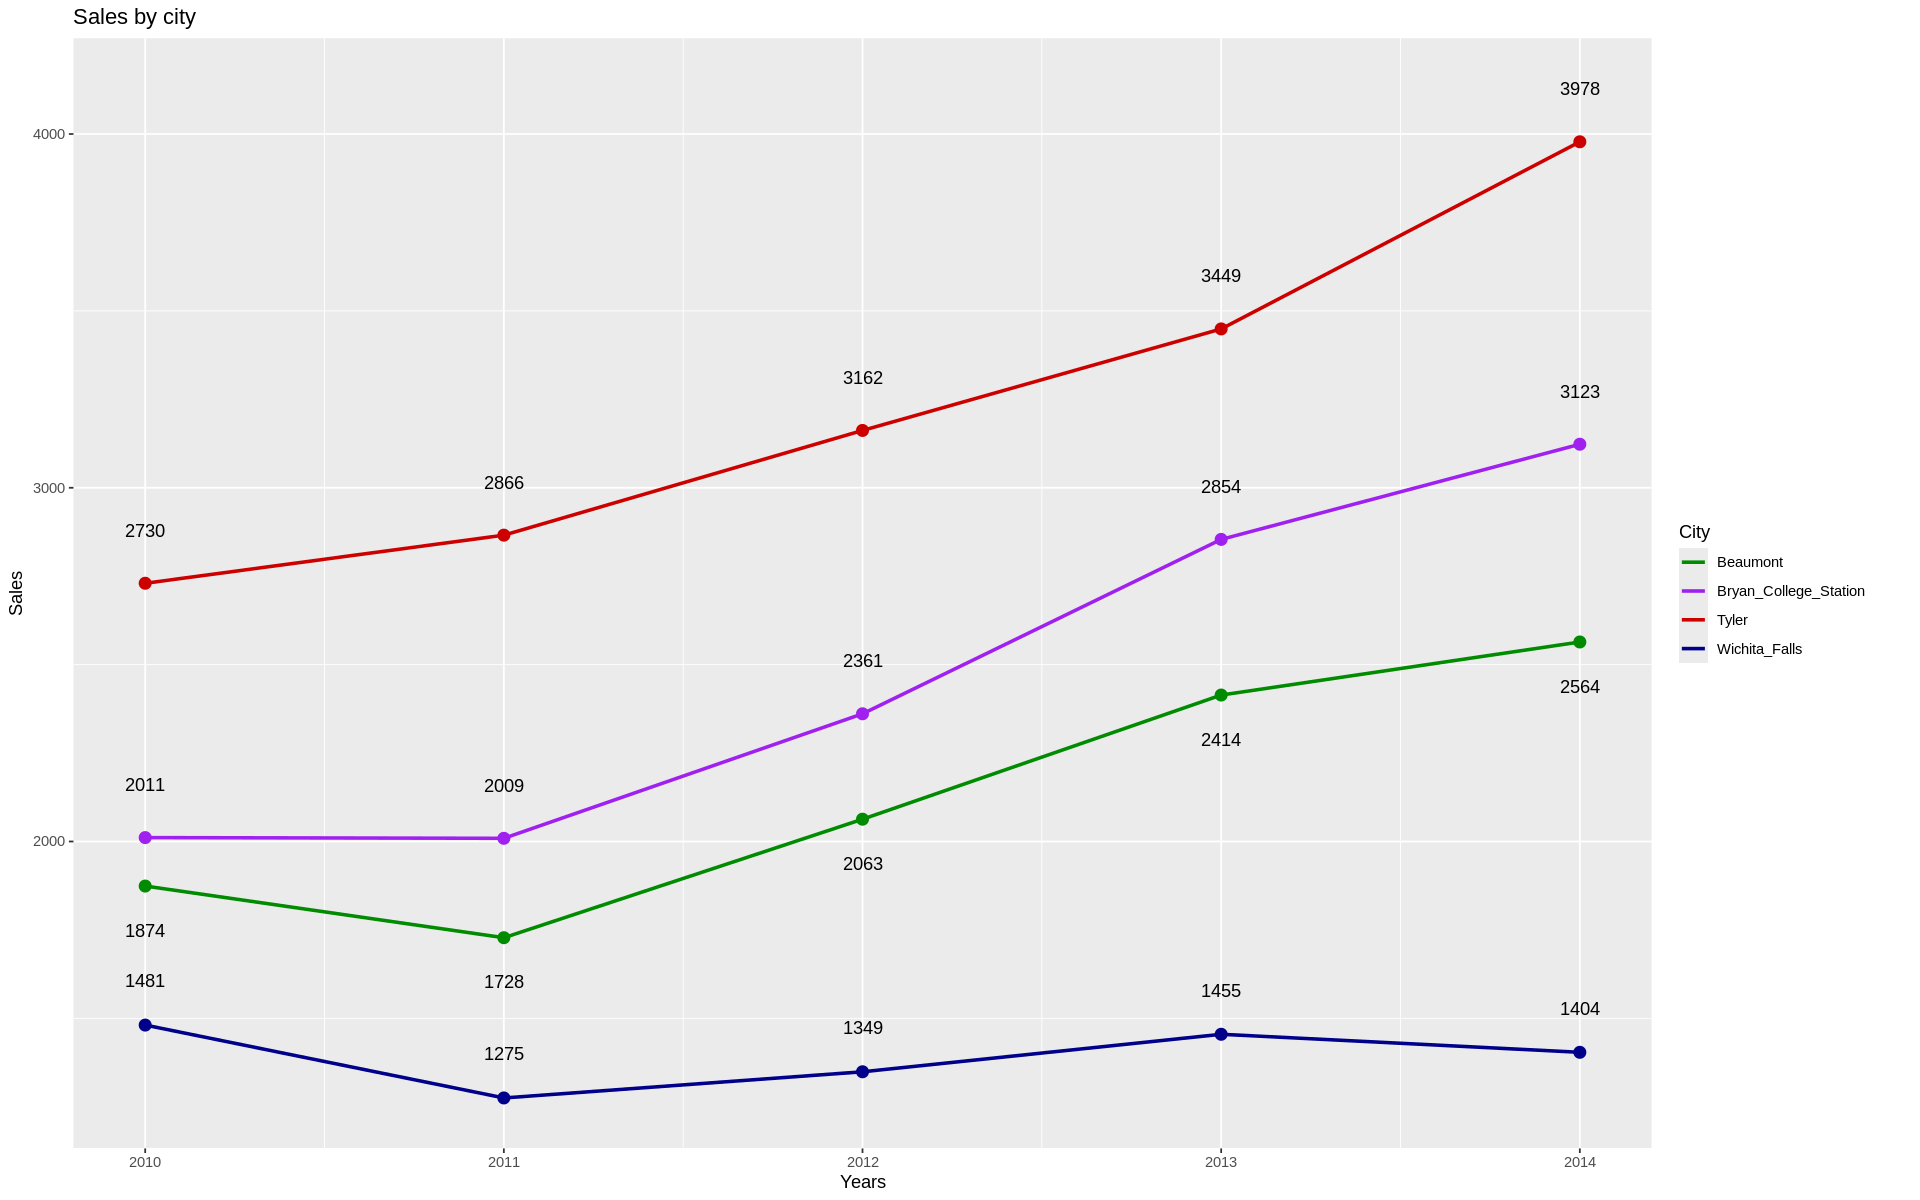

In [ ]:
# LINE CHART OF ANNUAL SALES FOR EACH CITY

ggplot(data = dataxlineachart) +
  geom_line(
    aes(x = Anno, y = Beaumont, col = "Beaumont"),
    lwd = 1
  ) +
  geom_line(
    aes(
      x = Anno,
      y = Bryan_College_Station,
      col = "Bryan_College_Station"
    ),
    lwd = 1
  ) +
  geom_line(
    aes(x = Anno, y = Tyler, col = "Tyler"),
    lwd = 1
  ) +
  geom_line(
    aes(x = Anno, y = Wichita_Falls, col = "Wichita_Falls"),
    lwd = 1
  ) +
  geom_point(
    aes(x = Anno, y = Beaumont),
    col = "green4",
    size = 3
  ) +
  geom_point(
    aes(x = Anno, y = Bryan_College_Station),
    col = "purple",
    size = 3
  ) +
  geom_point(
    aes(x = Anno, y = Tyler),
    col = "red3",
    size = 3
  ) +
  geom_point(
    aes(x = Anno, y = Wichita_Falls),
    col = "blue4",
    size = 3
  ) +
  labs(
    x = "Years",
    y = "Sales",
    title = "Sales by city"
  ) +
  scale_color_manual(
    name = "City",
    breaks = c(
      "Beaumont",
      "Bryan_College_Station",
      "Tyler",
      "Wichita_Falls"
    ),
    values = c("green4", "purple", "red3", "blue4"),
    labels = c(
      "Beaumont",
      "Bryan_College_Station",
      "Tyler",
      "Wichita_Falls"
    )
  ) +
  geom_text(
    aes(x = Anno, y = Beaumont - 125, label = Beaumont)
  ) +
  geom_text(
    aes(
      x = Anno,
      y = Bryan_College_Station + 150,
      label = Bryan_College_Station
    )
  ) +
  geom_text(
    aes(x = Anno, y = Tyler + 150, label = Tyler)
  ) +
  geom_text(
    aes(
      x = Anno,
      y = Wichita_Falls + 125,
      label = Wichita_Falls
    )
  )

# 10. Conclusions

The Texas real estate market can be analyzed along two dimensions: a temporal dimension, referring to trends over the years and within each year, and a spatial dimension, referring to comparisons across cities.

#

## Temporal Dimension

The line charts, both the overall one and the one disaggregated by city, the chart of the average number of sales conditioned on year, and the boxplot of total sales volume all show a decline in business activity between 2010 and 2011. If the dataset reflects real-world data, this could be a consequence of the 2008 financial crisis, whose effects may still have been present. From 2012 onward, however, a recovery emerges.

The middle months of the year, from April to August, are those in which business activity is most intense, as shown by the charts of the number and volume of sales. When disaggregating by city, the period from March to August records the highest number of sales for Tyler and especially for Bryan-College Station.

For Tyler, the number of sales remains high even in the months following August. This pattern is less pronounced for the lower-performing cities, although it is still present; in particular, it is more evident for Beaumont than for Wichita Falls.

#

## Spatial Dimension

Tyler is the city that records:

* the highest total and average number of sales;
* the highest monthly sales speed;
* the highest sales volume;
* the second-highest median price and the second-highest mean price, after Bryan-College Station.

Tyler appears to be a larger market than the other cities, considering the average number of active listings, and slightly less exclusive than Bryan-College Station, given its lower median price. The higher number of sales, driven not only by a greater number of listings but also by a faster sales rate, more than offsets the lower median and mean prices.

Bryan-College Station records:

* the third-highest average number of active listings;
* the second-highest total and average number of sales;
* the second-highest sales speed;
* the highest median and mean prices.

These results suggest that Bryan-College Station may represent a smaller market, given its third-highest average number of active listings, and a more exclusive one, considering its higher median and mean prices.

Wichita Falls and Beaumont are the lowest-performing cities across all the dimensions considered. Beaumont follows the same patterns as Tyler and Bryan-College Station in terms of sales, volumes, and mean and median prices, but at a lower level.